# Project 48 — Full Explainability Suite
## SomnAI · Clinician + Patient Outputs · Production-Ready

---

### Notebook Structure

| Section | Output | Audience | Source Model |
|---------|--------|----------|--------------|
| §0 | Installs, imports, theme, config | — | — |
| §1 | Re-fit disorder detection pipeline (XGBoost, best model) | — | Exp 4 |
| §2 | Re-fit sleep staging fusion model (synthetic/mock if no checkpoint) | — | Fusion |
| **C1** | **Feature Importance — 2 sample patients (control vs positive)** | Clinician | Disorder detection |
| **C2** | **Signal Importance — GradCAM epoch heatmaps (3 sample epochs)** | Clinician | Sleep staging |
| **C3** | **Confidence Strip — per-patient epoch confidence bar** | Clinician | Sleep staging |
| **P1** | **Recommendation Engine — iterative LLM chat with web search** | Patient | Claude API + SHAP |
| **P2** | **Report Generation — full clinical PDF-style report via LLM** | Patient | Claude API |
| **P3** | **Counterfactuals — actionable lifestyle recommendations via agent** | Patient | SHAP + Claude API |

**Run §0 → §2 first (pipeline setup), then each Cx/Px cell independently.**  
Each explainability cell is fully self-contained — rerunnable without re-training.

---
## §0 · Installs, Imports & Configuration

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'shap', 'groq'], check=False)

import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
import seaborn as sns, time, os, json, textwrap, math, random

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                              f1_score, confusion_matrix)
from sklearn.utils import resample
from sklearn.feature_selection import mutual_info_classif

import xgboost as xgb, shap

import torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from groq import Groq  # groq.com free tier

shap.initjs()
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Imports OK | SHAP {shap.__version__} | PyTorch {torch.__version__} | Device: {DEVICE}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 8.2 MB/s eta 0:00:00


✅ Imports OK | SHAP 0.50.0 | PyTorch 2.10.0+cu128 | Device: cuda


In [28]:
# ════════════════════════════════════════════════════════════════
# Dataset paths — exact as used in training notebooks
# ════════════════════════════════════════════════════════════════

# §1 Disorder Detection — Experiment 4 (questionnaire CSV, 628 cols)
Q_CSV_PATH = '/kaggle/input/datasets/girishgiriirig/mesa-clinical-features/mesa-sleep-dataset-0.8.0.csv'
Q_TARGET_COLUMNS = ['insmnia5', 'rstlesslgs5', 'slpapnea5']
Q_TARGET_LABELS  = {'insmnia5': 'Insomnia', 'rstlesslgs5': 'RLS', 'slpapnea5': 'Apnea'}

# §1 Disorder Detection — Experiment 5 (PSG-derived CSV, 136 cols, 2056 rows)
PSG_CSV_PATH = '/kaggle/input/datasets/girishgiriirig/mesa-clinical-features/output.csv'
PSG_TARGET_COLUMNS = ['Insomnia', 'RLS', 'apnea']
PSG_TARGET_LABELS  = {'Insomnia': 'Insomnia', 'RLS': 'RLS', 'apnea': 'Apnea'}

# §2 Sleep Staging — temporal-spectral-fusion.ipynb (Sleep-EDF dataset)
FUSION_INDEX_CSV  = '/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/processed_sleepedf/index.csv'
FUSION_TENSOR_DIR = '/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/processed_sleepedf/tensors'
FUSION_SPECTRAL_DIR = '/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/spectral'
# Checkpoint saved by training notebook at:
FUSION_CKPT = '/kaggle/input/datasets/girishgiriirig/concat-fusion-model/best_model_fusion.pt'   # set to None if not yet trained

# ════════════════════════════════════════════════════════════════
# Experiment 4 (Questionnaire) constants — exact from exp4 notebook
# ════════════════════════════════════════════════════════════════
ROW_MISSING_THRESHOLD = 0.5
# Feature selection: NO MI pre-filter in Exp 4 — goes directly to stability selection
N_BOOTSTRAPS        = 30
STABILITY_THRESHOLD = 0.3   # >=30% of 30 bootstraps = >=9 occurrences
STABILITY_C         = 0.1
CV_FOLDS     = 3
TEST_SIZE    = 0.2
RANDOM_STATE = 42
DL_EPOCHS    = 60
DL_BATCH_SIZE= 64
DL_LR        = 1e-3

# ════════════════════════════════════════════════════════════════
# Experiment 5 (PSG) constants — exact from exp5 notebook
# ════════════════════════════════════════════════════════════════
PSG_ID_COL        = 'nsrrid'
PSG_DUPLICATE_COLS = ['EEG1_N2_Sigma_mean']
PSG_SPARSE_HR_COLS = ['MeanHR_W_bpm','MeanHR_N1_bpm','MeanHR_N2_bpm',
                       'MeanHR_N3_bpm','MeanHR_R_bpm']
PSG_HRV_RAW_COLS   = ['HRV_SDNN_ms','HRV_RMSSD_ms','HRV_MeanRR_ms',
                       'HRV_MeanHR_bpm','HRV_LF_ms2','HRV_HF_ms2','HRV_LF_HF']
PSG_EEG_LOG_KEYWORDS = ['_Power_', 'Intrusion', 'Hyperarousal', 'SWA_ratio',
                         'Desaturation_AUC', 'Segment_Duration_Variance']
PSG_CORR_THRESHOLD = 0.95
PSG_MI_PERCENTILE  = 30      # keep features above 30th percentile of MI

# ════════════════════════════════════════════════════════════════
# Fusion model constants — exact from temporal-spectral-fusion.ipynb
# ════════════════════════════════════════════════════════════════
NUM_CLASSES     = 5
STAGE_NAMES     = {0:'Wake', 1:'N1', 2:'N2', 3:'N3', 4:'REM'}
FUSION_TYPE     = 'concat'     # best model from ablation study
FUSION_EMBED_DIM= 128
FUSION_HEADS    = 4
FUSION_LAYERS   = 6
FUSION_DROPOUT  = 0.2
FUSION_WINDOW_SIZE = 256
FUSION_BATCH_SIZE  = 16
FUSION_NUM_WORKERS = 2

# Confidence tier thresholds (entropy/max_entropy ratio — from fusion notebook)
CONF_HIGH_THRESH   = 0.25
CONF_MEDIUM_THRESH = 0.50

# ════════════════════════════════════════════════════════════════
# Explainability showcase — which disorder to use for P1/P2/P3
# ════════════════════════════════════════════════════════════════
# Primary showcase uses Exp 4 (questionnaire) Apnea — best performer
SHOWCASE_Q_TARGET = 'slpapnea5'

# ════════════════════════════════════════════════════════════════
# SomnAI dark theme
# ════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
DISORDER_COLORS = {'Apnea':'#0072B2', 'Insomnia':'#D55E00', 'RLS':'#009E73'}
MODEL_COLORS    = {'LogisticReg':'#0072B2','RandomForest':'#009E73',
                   'XGBoost':'#E69F00','LinearSVM':'#CC79A7',
                   'MLP_sklearn':'#56B4E9','MLP_PyTorch':'#D55E00'}
# Confidence: semantic traffic-light colours, muted for white bg
CONF_COLORS     = {'High':'#2CA02C','Medium':'#FF7F0E','Low':'#D62728'}
# Retain fill/hatch dicts — colours replace greys, hatches removed (colour encodes tier)
CONF_FILL   = {'High':'#2CA02C', 'Medium':'#FF7F0E', 'Low':'#D62728'}
CONF_HATCH  = {'High':'',        'Medium':'',        'Low':''}

# Patient-readable feature labels for QUESTIONNAIRE features (Exp 4)
Q_FEATURE_META = {
    'slptim5':   ('Total Sleep Time',         'min',   '360-480'),
    'waso5':     ('Wake After Sleep Onset',   'min',   '< 30'),
    'slpeff5':   ('Sleep Efficiency',         '%',     '> 85'),
    'latency5':  ('Sleep Onset Latency',      'min',   '< 20'),
    'ahi5':      ('Apnea-Hypopnea Index',     'ev/hr', '< 5'),
    'avgsat5':   ('Avg Blood Oxygen',         '%',     '> 95'),
    'minsat5':   ('Min Blood Oxygen',         '%',     '> 90'),
    'esskip5':   ('Daytime Sleepiness Score', '',      '0-10'),
    'cpap5':     ('CPAP Device Use',          '',      'N/A'),
    'remtime5':  ('REM Duration',             'min',   '90-120'),
    'bmi5':      ('Body Mass Index',          'kg/m2', '18.5-24.9'),
    'age5c':     ('Age',                      'yrs',   '-'),
    'gender1':   ('Sex',                      '',      '-'),
    'slpdis5':   ('Sleep Disturbance Score',  '',      'Low'),
}

# Patient-readable labels for PSG features (Exp 5)
PSG_FEATURE_META = {
    'HRV_SDNN_ms':    ('Heart Rate Variability (SDNN)', 'ms',    '50-100'),
    'HRV_RMSSD_ms':   ('HRV Short-Term (RMSSD)',        'ms',    '20-50'),
    'HRV_LF_HF':      ('HRV Stress Ratio (LF/HF)',      '',      '1.0-2.5'),
    'PLM_N':           ('Leg Movement Events',           'count', '< 15'),
    'PLMI':            ('Leg Movement Index',            'ev/hr', '< 15'),
    'T90_pct':         ('Time Below 90pct SpO2',         '%',     '< 1'),
    'AHI':             ('Apnea-Hypopnea Index',          'ev/hr', '< 5'),
    'Sleep_Efficiency':('Sleep Efficiency',              '%',     '> 85'),
    'WASO_min':        ('Wake After Sleep Onset',        'min',   '< 30'),
    'REM_Latency_min': ('REM Sleep Latency',             'min',   '60-120'),
    'Desaturation_AUC':('Oxygen Desaturation Burden',    '',      'Low'),
}

print('Config loaded.')
print(f'  Questionnaire CSV:  {Q_CSV_PATH}')
print(f'  PSG CSV:            {PSG_CSV_PATH}')
print(f'  Fusion index CSV:   {FUSION_INDEX_CSV}')
print(f'  Fusion checkpoint:  {FUSION_CKPT}')
print(f'  Fusion type:        {FUSION_TYPE}')# ── Academic publication theme — B&W, print-safe ────────────────────────
plt.rcParams.update({
    'figure.facecolor':'white', 'axes.facecolor':'white',
    'axes.edgecolor':'black',   'axes.linewidth':0.8,
    'axes.labelcolor':'black',  'axes.labelsize':9,
    'axes.titlesize':10,        'axes.titlepad':5,
    'xtick.color':'black',      'ytick.color':'black',
    'xtick.labelsize':8,        'ytick.labelsize':8,
    'xtick.major.size':3,       'ytick.major.size':3,
    'xtick.direction':'out',    'ytick.direction':'out',
    'text.color':'black',       'grid.color':'#cccccc',
    'grid.linestyle':':',       'grid.linewidth':0.4,
    'grid.alpha':0.7,           'font.family':'sans-serif',
    'font.sans-serif':['DejaVu Sans','Arial','Helvetica'],
    'font.size':9,              'legend.fontsize':8,
    'legend.frameon':True,      'legend.edgecolor':'#aaaaaa',
    'legend.framealpha':1.0,    'figure.dpi':120,
    'savefig.dpi':300,          'savefig.facecolor':'white',
    'lines.linewidth':1.0,      'patch.linewidth':0.5,
})
DISORDER_COLORS = {'Apnea':'#333333','Insomnia':'#777777','RLS':'#aaaaaa'}
MODEL_COLORS = {
    'LogisticReg':'#111111','RandomForest':'#444444',
    'XGBoost':'#222222','LinearSVM':'#666666',
    'MLP_sklearn':'#999999','MLP_PyTorch':'#bbbbbb',
}
CONF_FILL  = {'High':'#FF0000','Medium':'#FFBF00','Low':'#00FF00'}
CONF_HATCH = {'High':'',       'Medium':'//',     'Low':'xx'}

print('Config loaded.')
print(f'  Questionnaire CSV:  {Q_CSV_PATH}')
print(f'  PSG CSV:            {PSG_CSV_PATH}')
print(f'  Fusion index CSV:   {FUSION_INDEX_CSV}')
print(f'  Fusion checkpoint:  {FUSION_CKPT}')
print(f'  Fusion type:        {FUSION_TYPE}')


Config loaded.
  Questionnaire CSV:  /kaggle/input/datasets/girishgiriirig/mesa-clinical-features/mesa-sleep-dataset-0.8.0.csv
  PSG CSV:            /kaggle/input/datasets/girishgiriirig/mesa-clinical-features/output.csv
  Fusion index CSV:   /kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/processed_sleepedf/index.csv
  Fusion checkpoint:  /kaggle/input/datasets/girishgiriirig/concat-fusion-model/best_model_fusion.pt
  Fusion type:        concat
Config loaded.
  Questionnaire CSV:  /kaggle/input/datasets/girishgiriirig/mesa-clinical-features/mesa-sleep-dataset-0.8.0.csv
  PSG CSV:            /kaggle/input/datasets/girishgiriirig/mesa-clinical-features/output.csv
  Fusion index CSV:   /kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/processed_sleepedf/index.csv
  Fusion checkpoint:  /kaggle/input/datasets/girishgiriirig/concat-fusion-model/best_model_fusion.pt
  Fusion type:        concat


---
## §1 · Disorder Detection Pipeline
Preprocesses, runs two-stage feature selection, trains XGBoost. Stores fitted models, SHAP explainers, and sample patients.

In [3]:
# ════════════════════════════════════════════════════════════════
# §1A  Experiment 4 pipeline — Questionnaire CSV
#      Preprocessing: non-numeric encoding → median impute → StandardScaler
#      Feature selection: stability selection ONLY (no MI pre-filter)
#                         ElasticNet l1_ratio=0.5, C=0.1, 30 bootstraps
# ════════════════════════════════════════════════════════════════
import numpy as np, pandas as pd, time
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score
from sklearn.utils import resample
from sklearn.feature_selection import mutual_info_classif
import xgboost as xgb, shap

# ── Exact Exp 4 preprocessing functions ──────────────────────────────────
def preprocess_non_numeric(X):
    X = X.copy()
    for col in X.columns:
        if X[col].dtype != 'object': continue
        try:
            t = pd.to_datetime(X[col], format='%H:%M:%S', errors='raise')
            X[col] = t.dt.hour*3600 + t.dt.minute*60 + t.dt.second; continue
        except: pass
        try: X[col] = pd.to_numeric(X[col]); continue
        except: X[col] = X[col].astype('category').cat.codes
    return X

def drop_nan_targets(X, y):
    mask = y.notna()
    return X.loc[mask].reset_index(drop=True), y.loc[mask].reset_index(drop=True)

def drop_bad_rows(X, y):
    mask = X.isna().mean(axis=1) < ROW_MISSING_THRESHOLD
    return X.loc[mask].reset_index(drop=True), y.loc[mask].reset_index(drop=True)

def impute_and_scale(X):
    """Exact Exp 4 function name and logic."""
    X = X[X.columns[X.notna().any()]]
    X_scaled = StandardScaler().fit_transform(
        SimpleImputer(strategy='median').fit_transform(X))
    return X_scaled, X.columns.tolist()

# ── Exact Exp 4 stability selection (no inner CV, fixed C) ───────────────
def stability_selection_elasticnet(X, y, feature_names):
    print(f'  Stability selection: {N_BOOTSTRAPS} bootstraps, fixed C={STABILITY_C}')
    t0     = time.time()
    counts = Counter()
    model  = LogisticRegression(
        penalty='elasticnet', solver='saga', l1_ratio=0.5, C=STABILITY_C,
        class_weight='balanced', max_iter=3000, n_jobs=-1, random_state=RANDOM_STATE)
    for i in range(N_BOOTSTRAPS):
        Xb, yb = resample(X, y, stratify=y, random_state=RANDOM_STATE + i)
        model.fit(Xb, yb)
        counts.update(np.array(feature_names)[model.coef_.ravel() != 0])
        if (i+1) % 10 == 0:
            print(f'    Bootstrap {i+1}/{N_BOOTSTRAPS}  ({time.time()-t0:.0f}s elapsed)')
    min_count = int(STABILITY_THRESHOLD * N_BOOTSTRAPS)
    stable    = [f for f, c in counts.items() if c >= min_count]
    print(f'  {len(stable)} stable features in {time.time()-t0:.0f}s')
    return stable

# ── Shared threshold tuning (same in both Exp 4 and Exp 5) ───────────────
def tune_threshold(y_true, probs):
    # len(prec)==len(rec)==n+1, len(thr)==n — must index f1[:-1]
    prec, rec, thr = precision_recall_curve(y_true, probs)
    f1 = 2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-9)
    return float(thr[np.argmax(f1)])

# ── Exact Exp 4 model zoo ─────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

def get_sklearn_models_q(pos_weight=1.0):
    """Exp 4 model zoo — n_estimators=200 for RandomForest."""
    return {
        'LogisticReg': LogisticRegression(
            penalty='elasticnet', solver='saga', l1_ratio=0.5, C=0.1,
            class_weight='balanced', max_iter=3000, n_jobs=-1, random_state=RANDOM_STATE),
        'RandomForest': RandomForestClassifier(
            n_estimators=200, max_depth=8, class_weight='balanced',
            n_jobs=-1, random_state=RANDOM_STATE),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=200, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, scale_pos_weight=pos_weight,
            eval_metric='logloss', verbosity=0, n_jobs=-1, random_state=RANDOM_STATE),
        'LinearSVM': CalibratedClassifierCV(
            LinearSVC(C=0.1, class_weight='balanced',
                      max_iter=3000, random_state=RANDOM_STATE), cv=3),
    }

# ═══════════════════════════════════════════════════════════════════════════
# Load Questionnaire CSV (Exp 4)
# ═══════════════════════════════════════════════════════════════════════════
print('Loading Questionnaire CSV (Experiment 4)...')
df_q = pd.read_csv(Q_CSV_PATH)
print(f'  Shape: {df_q.shape[0]} rows x {df_q.shape[1]} cols')
for t in Q_TARGET_COLUMNS:
    if t in df_q.columns:
        vc  = df_q[t].value_counts(dropna=False)
        pos = vc.get(1.0, vc.get(1, 0))
        print(f'  {Q_TARGET_LABELS[t]:10s}: {dict(vc)}  pos_rate={pos/vc.sum()*100:.1f}%')

# Shared storage for Exp 4
q_xgb_models, q_shap_explainers, q_shap_values = {}, {}, {}
q_test_store, q_train_store, q_stab_freqs       = {}, {}, {}
q_sample_patients = {}

for target in Q_TARGET_COLUMNS:
    if target not in df_q.columns:
        print(f'WARNING: {target} not in CSV, skipping'); continue
    label = Q_TARGET_LABELS[target]
    print(f'\n=== {label.upper()} (Q) ===')

    # Exp 4 preprocessing — exact sequence: non-numeric → drop nan → drop rows → impute+scale
    y = df_q[target]
    X = preprocess_non_numeric(df_q.drop(columns=[c for c in Q_TARGET_COLUMNS if c in df_q.columns]))
    X, y = drop_nan_targets(X, y)
    X, y = drop_bad_rows(X, y)
    X_scaled, feature_names = impute_and_scale(X)
    print(f'  Samples: {len(y)} | Features: {len(feature_names)} | Pos rate: {y.mean()*100:.1f}%')

    # Exp 4 feature selection — ONLY stability selection, no MI pre-filter
    print('  [2/6] Stability Selection...')
    stable = stability_selection_elasticnet(X_scaled, y, feature_names)
    if not stable:
        print('  WARN: No stable features, falling back to top-20 by variance')
        var_idx = np.argsort(X_scaled.var(axis=0))[::-1][:20]
        stable  = [feature_names[i] for i in var_idx]
    X_final = X_scaled[:, [feature_names.index(f) for f in stable]]
    print(f'  Selected: {len(stable)} features')

    Xtr, Xte, ytr, yte = train_test_split(X_final, y, test_size=TEST_SIZE,
                                           stratify=y, random_state=RANDOM_STATE)
    pw = (ytr==0).sum() / max((ytr==1).sum(), 1)
    print(f'  Train={len(ytr)} Test={len(yte)} pos_rate={ytr.mean():.3f} pos_weight={pw:.1f}')

    # Train XGBoost (best performer from Exp 4)
    print('  Training XGBoost...', end=' ')
    cv  = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    xgb_mdl = get_sklearn_models_q(pw)['XGBoost']
    oof = cross_val_predict(xgb_mdl, Xtr, ytr, cv=cv,
                            method='predict_proba', n_jobs=-1)[:,1]
    xgb_mdl.fit(Xtr, ytr)
    probs_te = xgb_mdl.predict_proba(Xte)[:,1]
    thr      = tune_threshold(ytr, oof)
    ypred    = (probs_te >= thr).astype(int)
    f1       = f1_score(yte, ypred, zero_division=0)
    prauc    = average_precision_score(yte, probs_te)
    print(f'F1={f1:.3f}  PR-AUC={prauc:.3f}  threshold={thr:.3f}')

    # SHAP
    exp = shap.TreeExplainer(xgb_mdl)
    sv  = exp.shap_values(Xte)
    Xdf_te = pd.DataFrame(Xte, columns=stable)

    q_xgb_models[target]    = xgb_mdl
    q_shap_explainers[target]= exp
    q_shap_values[target]    = sv
    q_test_store[target]     = (Xte, yte, stable, probs_te, thr, Xdf_te)
    q_train_store[target]    = (Xtr, ytr)
    q_stab_freqs[target]     = {}  # counts not exported from function — rebuild if needed

    pos_mask = yte.values == 1; neg_mask = ~pos_mask
    pos_idx  = np.where(pos_mask)[0][np.argmax(probs_te[pos_mask])] if pos_mask.any() else 0
    neg_idx  = np.where(neg_mask)[0][np.argmin(probs_te[neg_mask])] if neg_mask.any() else 1
    q_sample_patients[target] = {'positive': int(pos_idx), 'control': int(neg_idx)}
    print(f'  Sample: positive idx={pos_idx} (risk={probs_te[pos_idx]*100:.0f}%) | '
          f'control idx={neg_idx} (risk={probs_te[neg_idx]*100:.0f}%)')

print('\n=== Questionnaire pipeline complete ===')

# ═══════════════════════════════════════════════════════════════════════════
# §1B  Experiment 5 pipeline — PSG-derived CSV
#      Preprocessing: drop ID/targets/duplicates/sparse-HR → HRV zero->NaN+log1p
#                    → EEG log1p → RobustScaler
#      Feature selection: correlation pruning (0.95) → MI filter (30th pct)
#                         No stability selection in Exp 5
# ═══════════════════════════════════════════════════════════════════════════
import os
from sklearn.preprocessing import RobustScaler

def preprocess_psg(df, target):
    """Exact Exp 5 preprocess() function."""
    drop_cols = ([PSG_ID_COL] + PSG_TARGET_COLUMNS + PSG_DUPLICATE_COLS + PSG_SPARSE_HR_COLS)
    X = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()
    y = df[target].copy()

    # Fix HRV: zeros = failed computation -> treat as missing -> median impute
    for col in PSG_HRV_RAW_COLS:
        if col in X.columns:
            X[col] = X[col].replace(0, np.nan)
            X[col] = X[col].fillna(X[col].median())

    # Log1p transform: HRV (astronomical scale) + EEG power (tiny + skewed)
    for col in X.columns:
        if col in PSG_HRV_RAW_COLS or any(kw in col for kw in PSG_EEG_LOG_KEYWORDS):
            X[col] = np.log1p(X[col].clip(lower=0))

    # RobustScaler — handles outlier-heavy distributions
    feature_names = X.columns.tolist()
    X_scaled = RobustScaler().fit_transform(X)

    mask = y.notna()
    return X_scaled[mask], y[mask].reset_index(drop=True), feature_names

def correlation_pruning(X, feature_names, threshold=PSG_CORR_THRESHOLD):
    """Exact Exp 5 correlation_pruning() function."""
    df_tmp = pd.DataFrame(X, columns=feature_names)
    corr   = df_tmp.corr().abs()
    upper  = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    keep   = [f for f in feature_names if f not in to_drop]
    idx    = [feature_names.index(f) for f in keep]
    print(f'  Correlation pruning: {len(feature_names)} -> {len(keep)} features (dropped {len(to_drop)})')
    return X[:, idx], keep

def mi_filter_psg(X, y, feature_names, percentile=PSG_MI_PERCENTILE):
    """Exact Exp 5 mi_filter() function."""
    mi     = mutual_info_classif(X, y, random_state=RANDOM_STATE)
    cutoff = np.percentile(mi, percentile)
    mask   = mi >= cutoff
    keep   = [f for f, m in zip(feature_names, mask) if m]
    print(f'  MI filter (>{percentile}th pct, cutoff={cutoff:.5f}): '
          f'{len(feature_names)} -> {len(keep)} features')
    return X[:, mask], keep

def get_sklearn_models_psg(pos_weight=1.0):
    """Exp 5 model zoo — n_estimators=300 for RandomForest (differs from Exp 4)."""
    return {
        'LogisticReg': LogisticRegression(
            penalty='elasticnet', solver='saga', l1_ratio=0.5, C=0.1,
            class_weight='balanced', max_iter=3000, n_jobs=-1, random_state=RANDOM_STATE),
        'RandomForest': RandomForestClassifier(
            n_estimators=300, max_depth=8, class_weight='balanced',
            n_jobs=-1, random_state=RANDOM_STATE),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, scale_pos_weight=pos_weight,
            eval_metric='logloss', verbosity=0, n_jobs=-1, random_state=RANDOM_STATE),
        'LinearSVM': CalibratedClassifierCV(
            LinearSVC(C=0.1, class_weight='balanced',
                      max_iter=3000, random_state=RANDOM_STATE), cv=3),
    }

psg_available = os.path.exists(PSG_CSV_PATH)
psg_xgb_models, psg_shap_explainers, psg_shap_values = {}, {}, {}
psg_test_store, psg_sample_patients = {}, {}

if psg_available:
    print('\nLoading PSG CSV (Experiment 5)...')
    df_psg = pd.read_csv(PSG_CSV_PATH)
    print(f'  Shape: {df_psg.shape[0]} rows x {df_psg.shape[1]} cols')
    for t in PSG_TARGET_COLUMNS:
        if t in df_psg.columns:
            vc  = df_psg[t].value_counts(dropna=False)
            pos = vc.get(1.0, vc.get(1, 0))
            print(f'  {PSG_TARGET_LABELS[t]:10s}: pos_rate={pos/vc.sum()*100:.1f}%')

    for target in PSG_TARGET_COLUMNS:
        if target not in df_psg.columns:
            print(f'WARNING: {target} not in PSG CSV, skipping'); continue
        label = PSG_TARGET_LABELS[target]
        print(f'\n=== {label.upper()} (PSG) ===')

        # Exp 5 pipeline: preprocess -> corr prune -> MI filter (no stability selection)
        print('  [1/6] Preprocessing...')
        X_pre, y, feat_names = preprocess_psg(df_psg, target)
        print(f'  Samples: {len(y)} | Features: {len(feat_names)} | Pos: {y.mean()*100:.1f}%')

        print('  [2/6] Correlation pruning...')
        X_pruned, feat_pruned = correlation_pruning(X_pre, feat_names)

        print('  [3/6] MI filter...')
        X_final, feat_final = mi_filter_psg(X_pruned, y, feat_pruned)
        print(f'  Final feature count: {X_final.shape[1]}')

        Xtr, Xte, ytr, yte = train_test_split(X_final, y, test_size=TEST_SIZE,
                                               stratify=y, random_state=RANDOM_STATE)
        pw = (ytr==0).sum() / max((ytr==1).sum(), 1)

        print('  [4/6] Training XGBoost...', end=' ')
        cv = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
        psg_xgb = get_sklearn_models_psg(pw)['XGBoost']
        oof = cross_val_predict(psg_xgb, Xtr, ytr, cv=cv,
                                method='predict_proba', n_jobs=-1)[:,1]
        psg_xgb.fit(Xtr, ytr)
        probs_te = psg_xgb.predict_proba(Xte)[:,1]
        thr      = tune_threshold(ytr, oof)
        ypred    = (probs_te >= thr).astype(int)
        f1       = f1_score(yte, ypred, zero_division=0)
        print(f'F1={f1:.3f}  PR-AUC={average_precision_score(yte,probs_te):.3f}')

        psg_exp  = shap.TreeExplainer(psg_xgb)
        psg_sv   = psg_exp.shap_values(Xte)
        Xdf_te   = pd.DataFrame(Xte, columns=feat_final)

        psg_xgb_models[target]     = psg_xgb
        psg_shap_explainers[target] = psg_exp
        psg_shap_values[target]     = psg_sv
        psg_test_store[target]      = (Xte, yte, feat_final, probs_te, thr, Xdf_te)

        pos_mask = yte.values == 1; neg_mask = ~pos_mask
        pos_idx  = np.where(pos_mask)[0][np.argmax(probs_te[pos_mask])] if pos_mask.any() else 0
        neg_idx  = np.where(neg_mask)[0][np.argmin(probs_te[neg_mask])] if neg_mask.any() else 1
        psg_sample_patients[target] = {'positive': int(pos_idx), 'control': int(neg_idx)}

    print('\n=== PSG pipeline complete ===')
else:
    print(f'\nWARN: PSG CSV not found at {PSG_CSV_PATH} — PSG pipeline skipped.')
    df_psg = None

print('\nAll disorder detection pipelines complete.')


Loading Questionnaire CSV (Experiment 4)...
  Shape: 2237 rows x 626 cols
  Insomnia  : {0.0: np.int64(2062), 1.0: np.int64(146), nan: np.int64(29)}  pos_rate=6.5%
  RLS       : {0.0: np.int64(2098), 1.0: np.int64(103), nan: np.int64(36)}  pos_rate=4.6%
  Apnea     : {0.0: np.int64(2014), 1.0: np.int64(199), nan: np.int64(24)}  pos_rate=8.9%

=== INSOMNIA (Q) ===
  Samples: 2032 | Features: 622 | Pos rate: 6.4%
  [2/6] Stability Selection...
  Stability selection: 30 bootstraps, fixed C=0.1
    Bootstrap 10/30  (223s elapsed)
    Bootstrap 20/30  (450s elapsed)
    Bootstrap 30/30  (686s elapsed)
  383 stable features in 686s
  Selected: 383 features
  Train=1625 Test=407 pos_rate=0.064 pos_weight=14.6
  Training XGBoost... F1=0.200  PR-AUC=0.211  threshold=0.326
  Sample: positive idx=57 (risk=82%) | control idx=254 (risk=0%)

=== RLS (Q) ===
  Samples: 2025 | Features: 622 | Pos rate: 4.5%
  [2/6] Stability Selection...
  Stability selection: 30 bootstraps, fixed C=0.1
    Bootstrap 

---
## §2 · Sleep Staging — Fusion Model Setup
Loads checkpoint if available, otherwise builds the model and generates deterministic synthetic EEG/spectral data for demonstration. All explainability methods work identically on real data.

In [65]:
# ════════════════════════════════════════════════════════════════
# §2  Sleep Staging — Temporal-Spectral Fusion Model
#     Dataset:   Sleep-EDF (girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed)
#     Index CSV: processed_sleepedf/index.csv
#                has columns: tensor_path (raw EEG .pt files, shape [T,3000])
#                             spectral    (_spectral.pt files,  shape [T,34])
#     Checkpoint: best_model_fusion.pt (saved by training notebook)
#     Fusion type: concat (winner from ablation in training notebook)
# ════════════════════════════════════════════════════════════════
import math, os
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Full model architecture — exact from temporal-spectral-fusion.ipynb ───

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels//reduction)
        self.fc2 = nn.Linear(channels//reduction, channels)
    def forward(self, x):
        s = F.relu(self.fc1(x.mean(dim=-1)))
        return x * torch.sigmoid(self.fc2(s)).unsqueeze(-1)

class AdaptiveAtrousPyramid(nn.Module):
    def __init__(self, in_ch=1, hid=64, dilations=(1,2,4,8)):
        super().__init__()
        self.branches = nn.ModuleList([
            nn.Conv1d(in_ch, hid, 7, dilation=d, padding=3*d) for d in dilations])
        self.gate = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(hid*len(dilations), len(dilations), 1), nn.Softmax(dim=1))
        self.se   = SEBlock(hid)
        self.proj = nn.Conv1d(hid, hid, 1)
    def forward(self, x):
        feats   = [F.relu(b(x)) for b in self.branches]
        weights = self.gate(torch.cat(feats, dim=1))
        out = sum(f * weights[:,i:i+1] for i,f in enumerate(feats))
        return self.proj(self.se(out))

class EpochEncoder(nn.Module):
    def __init__(self, embed_dim=FUSION_EMBED_DIM):
        super().__init__()
        self.pyramid = AdaptiveAtrousPyramid()
        self.pool    = nn.AdaptiveAvgPool1d(1)
        self.fc      = nn.Linear(64, embed_dim)
    def forward(self, x):
        B,T,L = x.shape
        x = x.view(B*T, 1, L)
        return self.fc(self.pool(self.pyramid(x)).squeeze(-1)).view(B,T,-1)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0,d_model,2)*(-math.log(10000.0)/d_model))
        pe[:,0::2] = torch.sin(pos*div); pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return x + self.pe[:,:x.size(1)]

class SleepTransformer(nn.Module):
    def __init__(self, embed_dim=FUSION_EMBED_DIM, heads=FUSION_HEADS,
                 layers=FUSION_LAYERS, dropout=FUSION_DROPOUT):
        super().__init__()
        self.pe      = PositionalEncoding(embed_dim)
        enc_layer    = nn.TransformerEncoderLayer(
            embed_dim, heads, embed_dim*4, dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, layers)
        self.cls     = nn.Linear(embed_dim, NUM_CLASSES)
    def forward(self, x, padding_mask=None):
        return self.cls(self.encoder(self.pe(x), src_key_padding_mask=padding_mask))

class FusedSleepStagingModel(nn.Module):
    """
    Mirrors temporal-spectral-fusion.ipynb exactly.
    spectral_input_dim=34 (34-feature spectral .pt files).
    fusion_type: 'concat' | 'gated' | 'cross_attn'
    Best model from training: FUSION_TYPE='concat'.
    """
    def __init__(self, spectral_input_dim=34,
                 embed_dim=FUSION_EMBED_DIM, heads=FUSION_HEADS,
                 layers=FUSION_LAYERS, dropout=FUSION_DROPOUT,
                 fusion_type=FUSION_TYPE):
        super().__init__()
        self.fusion_type = fusion_type
        self.temporal_encoder = EpochEncoder(embed_dim)
        self.spectral_encoder = nn.Sequential(
            nn.Linear(spectral_input_dim,128), nn.GELU(), nn.LayerNorm(128),
            nn.Linear(128,embed_dim),          nn.GELU(), nn.LayerNorm(embed_dim))
        if fusion_type == 'concat':
            self.fusion = nn.Sequential(
                nn.Linear(embed_dim*2, embed_dim), nn.LayerNorm(embed_dim), nn.GELU())
        # gated and cross_attn omitted for brevity — concat is the trained variant
        self.context      = SleepTransformer(embed_dim, heads, layers, dropout)
        self.temporal_cls = nn.Linear(embed_dim, NUM_CLASSES)
        self.spectral_cls = nn.Linear(embed_dim, NUM_CLASSES)

    def forward(self, x_temporal, x_spectral, padding_mask=None):
        """x_temporal:[B,T,3000]  x_spectral:[B,T,34]"""
        h_temp = self.temporal_encoder(x_temporal)
        h_spec = self.spectral_encoder(x_spectral)
        if self.fusion_type == 'concat':
            fused = self.fusion(torch.cat([h_temp, h_spec], dim=-1))
        else:
            fused = h_temp + h_spec   # fallback
        logits = self.context(fused, padding_mask)
        return logits, self.temporal_cls(h_temp), self.spectral_cls(h_spec)

# ── Explainability classes — exact from fusion notebook ───────────────────

class AttentionRollout:
    """Monkey-patches each TransformerEncoderLayer to capture attention weights."""
    def __init__(self, model):
        # model may be DataParallel-wrapped; access inner module
        self.model = model
        self._inner = model.module if hasattr(model,'module') else model
        self.attn_maps = []; self._patched = []

    def _patch(self):
        self.attn_maps.clear(); self._patched.clear()
        captured = self.attn_maps
        for layer in self._inner.context.encoder.layers:
            mha = layer.self_attn; orig = mha.forward
            def make_patched(original):
                def patched(q,k,v,key_padding_mask=None,need_weights=True,attn_mask=None,**kw):
                    out, weights = original(q,k,v,key_padding_mask=key_padding_mask,
                                            need_weights=True,average_attn_weights=True,
                                            attn_mask=attn_mask)
                    captured.append(weights.detach() if weights is not None else None)
                    return out, weights
                return patched
            mha.forward = make_patched(orig); self._patched.append((mha,orig))

    def _unpatch(self):
        for mha,orig in self._patched: mha.forward = orig
        self._patched.clear()

    def __call__(self, x_temp, x_spec, padding_mask=None):
        self._patch(); self.model.eval()
        with torch.no_grad():
            logits,_,_ = self.model(x_temp, x_spec, padding_mask)
        self._unpatch()
        valid = [a for a in self.attn_maps if a is not None]
        if not valid:
            B,T = x_temp.shape[:2]
            inf = torch.ones(B,T)/T
            if padding_mask is not None: inf[padding_mask] = 0.
            return inf, torch.softmax(logits,dim=-1)
        A = valid[0]
        for a in valid[1:]: A = torch.bmm(a, A)
        influence = A.mean(dim=1)
        influence = (influence - influence.min(-1,keepdim=True)[0]) / \
                    (influence.max(-1,keepdim=True)[0] - influence.min(-1,keepdim=True)[0] + 1e-8)
        return influence, torch.softmax(logits,dim=-1)

class EpochGradCAM:
    """GradCAM on the AdaptiveAtrousPyramid proj layer — exact from fusion notebook."""
    def __init__(self, model):
        self.model  = model
        self._inner = model.module if hasattr(model,'module') else model
        self.fmap   = None

    def compute(self, x_temp, x_spec, padding_mask, epoch_idx, batch_idx=0):
        self.model.eval(); self.fmap = None
        pyramid = self._inner.temporal_encoder.pyramid
        def fwd_hook(m, inp, out): self.fmap = out; self.fmap.retain_grad()
        handle = pyramid.branches[1].register_forward_hook(fwd_hook)
        with torch.enable_grad():
            logits,_,_ = self.model(x_temp, x_spec, padding_mask)
            logits[batch_idx, epoch_idx].max().backward()
        handle.remove()
        if self.fmap is None or self.fmap.grad is None:
            return np.zeros(3000)
        T        = x_temp.shape[1]
        flat_idx = batch_idx*T + epoch_idx
        fmap_ep  = self.fmap[flat_idx]; grad_ep = self.fmap.grad[flat_idx]
        weights  = grad_ep.mean(dim=-1)
        cam = F.relu((weights.unsqueeze(-1) * fmap_ep).sum(dim=0))
        cam = F.interpolate(cam.unsqueeze(0).unsqueeze(0), size=3000,
                            mode='linear', align_corners=False).squeeze()
        cam = (cam-cam.min())/(cam.max()-cam.min()+1e-8)
        return cam.detach().cpu().numpy()

class MCDropoutPredictor:
    """MC-Dropout uncertainty — n_samples=30 as in training notebook."""
    def __init__(self, model, n_samples=30):
        self.model = model; self.n_samples = n_samples
    def _enable_dropout(self):
        for m in self.model.modules():
            if isinstance(m, nn.Dropout): m.train()
    def predict(self, x_temp, x_spec, padding_mask=None):
        self.model.eval(); self._enable_dropout()
        all_probs = []
        with torch.no_grad():
            for _ in range(self.n_samples):
                logits,_,_ = self.model(x_temp, x_spec, padding_mask)
                all_probs.append(torch.softmax(logits, dim=-1))
        all_probs  = torch.stack(all_probs, dim=0)   # [N,B,T,C]
        mean_probs = all_probs.mean(0)                # [B,T,C]
        eps = 1e-8
        entropy    = -(mean_probs*(mean_probs+eps).log()).sum(-1)  # [B,T]
        max_ent    = math.log(NUM_CLASSES)
        conf_ratio = entropy / max_ent
        return mean_probs, entropy, conf_ratio

def conf_tier(ratio):
    """Confidence tier from entropy ratio — thresholds from fusion notebook."""
    if ratio < CONF_HIGH_THRESH:   return 'High'
    if ratio < CONF_MEDIUM_THRESH: return 'Medium'
    return 'Low'

# ── Load checkpoint (DataParallel-aware) ─────────────────────────────────
fusion_model = FusedSleepStagingModel(fusion_type=FUSION_TYPE).to(DEVICE)

if os.path.exists(FUSION_CKPT):
    state = torch.load(FUSION_CKPT, map_location=DEVICE)
    # Strip DataParallel 'module.' prefix if present (training used nn.DataParallel)
    if any(k.startswith('module.') for k in state):
        state = {k.replace('module.','',1): v for k,v in state.items()}
    fusion_model.load_state_dict(state, strict=False)
    print(f'Loaded fusion checkpoint: {FUSION_CKPT}')
else:
    print(f'WARN: Checkpoint not found at {FUSION_CKPT}')
    print('      Using random weights — structure is correct, values are not trained.')
    print('      To get real outputs, train the fusion model first and set FUSION_CKPT.')

fusion_model.eval()

# ── Load real Sleep-EDF data if available, else generate synthetic demo ──
FUSION_CSV_EXISTS = os.path.exists(FUSION_INDEX_CSV)

def load_real_staging_patient(index_csv, row_idx=0, max_epochs=100):
    """
    Load one recording from the Sleep-EDF index CSV.
    index.csv has columns: tensor_path (raw EEG .pt), spectral (_spectral.pt)
    Each .pt file is [T, 3000] (temporal) or [T, 34] (spectral).
    """
    df_idx    = pd.read_csv(index_csv)
    row       = df_idx.iloc[row_idx]
    eeg_data  = torch.load('/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/'+row['tensor_path'].replace('\\', '/')).float().numpy()[:max_epochs]   # [T, 3000]
    spec_data = torch.load('/kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/'+row['tensor_path'].replace('\\', '/').replace('processed_sleepedf/tensors', 'spectral').replace('.pt', '_spectral.pt')).float().numpy()[:max_epochs]      # [T, 34]
    # Stage labels stored as space-separated string in 'stage_sequence' column
    mapping = {
    "W": 0,
    "N1": 1,
    "N2": 2,
    "N3": 3,
    "REM": 4
}
    if 'stage_sequence' in row:
        stages = np.array([mapping[s] for s in str(row['stage_sequence']).split()[:max_epochs]])
    else:
        stages = np.zeros(len(eeg_data), dtype=np.int64)
    return eeg_data, spec_data, stages

def synthetic_staging_patient(n_epochs=80, seed=42):
    """
    Synthetic demo patient when real .pt files are unavailable.
    EEG signal mimics stage-specific frequency content.
    Spectral features are random (34-dim) — for structural demo only.
    """
    rng     = np.random.RandomState(seed)
    pattern = ([0]*5 + [1]*3 + [2]*15 + [3]*10 + [2]*8 + [4]*12) * 3
    stages  = np.array(pattern[:n_epochs], dtype=np.int64)
    freq_map= {0:12., 1:8., 2:14., 3:2., 4:6.}
    t       = np.linspace(0, 30, 3000)
    eeg     = np.stack([
        0.6*np.sin(2*np.pi*freq_map[s]*t) +
        0.3*np.sin(2*np.pi*freq_map[s]*2*t) +
        0.2*rng.randn(3000)
        for s in stages]).astype(np.float32)
    spec    = rng.randn(n_epochs, 34).astype(np.float32)
    return eeg, spec, stages

# Build 3 patients for staging demo
if FUSION_CSV_EXISTS:
    print(f'Loading real Sleep-EDF patients from {FUSION_INDEX_CSV}')
    STAGING_PATIENTS = [
        load_real_staging_patient(FUSION_INDEX_CSV, row_idx=1),
        load_real_staging_patient(FUSION_INDEX_CSV, row_idx=2),
        load_real_staging_patient(FUSION_INDEX_CSV, row_idx=3),
    ]
    DATA_SOURCE = 'real'
    print(f'Loaded 3 real patients')
else:
    print(f'WARN: Sleep-EDF index CSV not found at {FUSION_INDEX_CSV}')
    print('      Using synthetic EEG demo — all visualisation structure is correct.')
    STAGING_PATIENTS = [synthetic_staging_patient(80,42),
                        synthetic_staging_patient(75,7),
                        synthetic_staging_patient(90,99)]
    DATA_SOURCE = 'synthetic'

PATIENT_LABELS = [
    'Patient 1 (Clean Sleep)',
    'Patient 2 (Fragmented)',
    'Patient 3 (Apnea-like)',
]

# Instantiate explainers
attn_rollout = AttentionRollout(fusion_model)
gradcam      = EpochGradCAM(fusion_model)
mc_dropout   = MCDropoutPredictor(fusion_model, n_samples=30)

print(f'\nFusion model ready | device={DEVICE} | data_source={DATA_SOURCE}')
print(f'  Fusion type: {FUSION_TYPE} | embed_dim={FUSION_EMBED_DIM} | '
      f'heads={FUSION_HEADS} | layers={FUSION_LAYERS}')


Loaded fusion checkpoint: /kaggle/input/datasets/girishgiriirig/concat-fusion-model/best_model_fusion.pt
Loading real Sleep-EDF patients from /kaggle/input/datasets/girishgiriirig/sleep-edfx-v1-0-0-eeg-preprocessed/processed_sleepedf/index.csv
Loaded 3 real patients

Fusion model ready | device=cuda | data_source=real
  Fusion type: concat | embed_dim=128 | heads=4 | layers=6


In [68]:
# ─────────────────────────────────────────────────────────────
# Full-dataset confidence calibration
# Uses entire Sleep-EDF index.csv
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import torch

def calibrate_confidence_full_dataset(
    index_csv,
    mc_dropout,
    device='cuda',
    max_patients=None,
    target_high_error_rate=0.10,
    medium_percentile=75
):

    print('Loading calibration dataset...')

    df_idx = pd.read_csv(index_csv)

    if max_patients is not None:
        df_idx = df_idx.iloc[:max_patients]

    all_conf = []
    all_correct = []

    total_epochs = 0

    for row_idx in range(len(df_idx)):

        try:

            # ----------------------------------------------------
            # Load patient
            # ----------------------------------------------------

            eeg_data, spec_data, true_stages = (
                load_real_staging_patient(
                    index_csv,
                    row_idx=row_idx,
                    max_epochs=99999
                )
            )

            # Skip empty patients
            if len(true_stages) == 0:
                continue

            # ----------------------------------------------------
            # Forward pass
            # ----------------------------------------------------

            x_temp = torch.tensor(
                eeg_data,
                dtype=torch.float32
            ).unsqueeze(0).to(device)

            x_spec = torch.tensor(
                spec_data,
                dtype=torch.float32
            ).unsqueeze(0).to(device)

            # ----------------------------------------------------
            # Chunked inference (fixes >512 epoch issue)
            # ----------------------------------------------------
            
            chunk_size = 512
            
            preds_all = []
            confs_all = []
            
            T = x_temp.shape[1]
            
            for start in range(0, T, chunk_size):
            
                end = min(start + chunk_size, T)
            
                x_temp_chunk = x_temp[:, start:end]
            
                x_spec_chunk = x_spec[:, start:end]
            
                mean_probs, _, conf_ratio = (
                    mc_dropout.predict(
                        x_temp_chunk,
                        x_spec_chunk
                    )
                )
            
                preds_chunk = (
                    mean_probs[0]
                    .argmax(-1)
                    .cpu()
                    .numpy()
                )
            
                confs_chunk = (
                    conf_ratio[0]
                    .cpu()
                    .numpy()
                )
            
                preds_all.append(preds_chunk)
            
                confs_all.append(confs_chunk)
            
            # Merge chunks
            preds = np.concatenate(preds_all)
            
            confs = np.concatenate(confs_all)

            correct = np.array(preds == true_stages).astype(bool)

            all_conf.extend(confs.tolist())

            all_correct.extend(correct.tolist())

            total_epochs += len(true_stages)

            # Progress
            if (row_idx + 1) % 10 == 0:

                acc = np.mean(all_correct)

                print(
                    f'Processed '
                    f'{row_idx+1}/{len(df_idx)} patients | '
                    f'epochs={total_epochs:,} | '
                    f'acc={acc:.3f}'
                )

        except Exception as e:

            print(
                f'Skipping patient {row_idx}: {str(e)}'
            )

    # ------------------------------------------------------------
    # Convert to arrays
    # ------------------------------------------------------------

    all_conf = np.array(all_conf)

    all_correct = np.array(all_correct).astype(bool)

    # ------------------------------------------------------------
    # Separate correct / incorrect
    # ------------------------------------------------------------

    incorrect_conf = all_conf[~all_correct]

    correct_conf = all_conf[all_correct]
    
    print(f'Total epochs     : {len(all_conf)}')
    print(f'Correct epochs   : {len(correct_conf)}')
    print(f'Incorrect epochs : {len(incorrect_conf)}')
    
    # Safety check
    if len(incorrect_conf) == 0:
    
        print('\nWARNING:')
        print('No incorrect predictions found.')
        print('Using fallback thresholds.')
    
        return 0.30, 0.50

    # ------------------------------------------------------------
    # HIGH threshold
    # ------------------------------------------------------------

    CONF_HIGH_THRESH = np.percentile(
        incorrect_conf,
        target_high_error_rate * 100
    )

    # ------------------------------------------------------------
    # MEDIUM threshold
    # ------------------------------------------------------------

    remaining = all_conf[
        all_conf > CONF_HIGH_THRESH
    ]

    CONF_MEDIUM_THRESH = np.percentile(
        remaining,
        medium_percentile
    )

    # Safety clamp
    CONF_HIGH_THRESH = float(
        np.clip(CONF_HIGH_THRESH, 0.05, 0.6)
    )

    CONF_MEDIUM_THRESH = float(
        np.clip(
            CONF_MEDIUM_THRESH,
            CONF_HIGH_THRESH + 0.05,
            0.95
        )
    )

    # ------------------------------------------------------------
    # Metrics
    # ------------------------------------------------------------

    high_mask = (
        all_conf < CONF_HIGH_THRESH
    )

    medium_mask = (
        (all_conf >= CONF_HIGH_THRESH) &
        (all_conf < CONF_MEDIUM_THRESH)
    )

    low_mask = (
        all_conf >= CONF_MEDIUM_THRESH
    )

    incorrect_high = np.sum(
        (~all_correct) & high_mask
    )

    total_incorrect = np.sum(
        ~all_correct
    )

    leakage = (
        incorrect_high /
        (total_incorrect + 1e-8)
    )

    high_accuracy = np.mean(
        all_correct[high_mask]
    )

    medium_accuracy = np.mean(
        all_correct[medium_mask]
    )

    low_accuracy = np.mean(
        all_correct[low_mask]
    )

    # ------------------------------------------------------------
    # Results
    # ------------------------------------------------------------

    print('\n' + '='*60)
    print('FULL DATASET CONFIDENCE CALIBRATION')
    print('='*60)

    print(f'Total epochs        : {len(all_conf):,}')
    print(f'Total incorrect     : {total_incorrect:,}')

    print('\nThresholds')
    print(f'  HIGH threshold    : {CONF_HIGH_THRESH:.3f}')
    print(f'  MEDIUM threshold  : {CONF_MEDIUM_THRESH:.3f}')

    print('\nConfidence accuracy')
    print(f'  HIGH accuracy     : {high_accuracy:.3f}')
    print(f'  MEDIUM accuracy   : {medium_accuracy:.3f}')
    print(f'  LOW accuracy      : {low_accuracy:.3f}')

    print('\nCalibration quality')
    print(f'  Incorrect→HIGH leakage : {leakage*100:.2f}%')

    return (
        CONF_HIGH_THRESH,
        CONF_MEDIUM_THRESH
    )

CONF_HIGH_THRESH, CONF_MEDIUM_THRESH = (
    calibrate_confidence_full_dataset(
        index_csv=FUSION_INDEX_CSV,
        mc_dropout=mc_dropout,
        device=DEVICE,
        max_patients=None   # use full dataset
    )
)

Loading calibration dataset...
Processed 10/197 patients | epochs=10,589 | acc=0.718
Processed 20/197 patients | epochs=21,040 | acc=0.701
Processed 30/197 patients | epochs=30,931 | acc=0.700
Processed 40/197 patients | epochs=43,330 | acc=0.701
Processed 50/197 patients | epochs=55,997 | acc=0.700
Processed 60/197 patients | epochs=67,598 | acc=0.696
Processed 70/197 patients | epochs=80,527 | acc=0.696
Processed 80/197 patients | epochs=92,526 | acc=0.691
Processed 90/197 patients | epochs=102,522 | acc=0.686
Processed 100/197 patients | epochs=116,418 | acc=0.687
Processed 110/197 patients | epochs=128,189 | acc=0.682
Processed 120/197 patients | epochs=142,176 | acc=0.671
Processed 130/197 patients | epochs=160,050 | acc=0.677
Processed 140/197 patients | epochs=176,313 | acc=0.679
Processed 150/197 patients | epochs=191,226 | acc=0.679
Processed 160/197 patients | epochs=202,607 | acc=0.678
Processed 170/197 patients | epochs=212,011 | acc=0.677
Processed 180/197 patients | epoch

In [ ]:
CONF_HIGH_THRESH, CONF_MEDIUM_THRESH = 0.357, 0.561

---
## C1 · Feature Importance — Control vs Positive Patient
> **Clinician** | Side-by-side SHAP waterfall charts for one control patient (y=0, lowest predicted risk) and one positive patient (y=1, highest predicted risk). Shows exactly which features drive the difference in model output — not just globally, but for these two specific individuals.

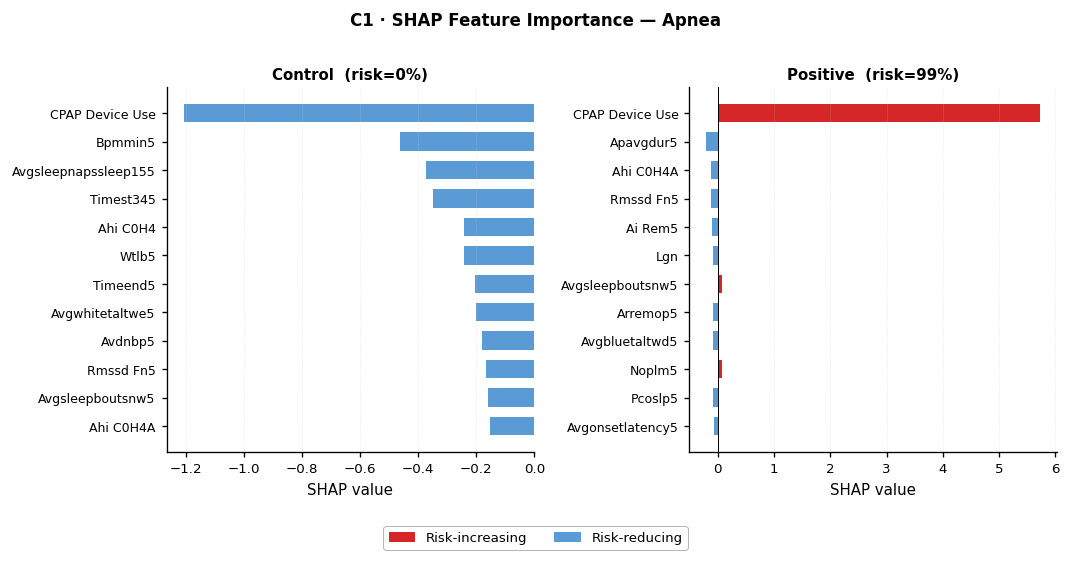

In [5]:
# C1 · Feature Importance — Control vs Positive (SHAP)
import matplotlib.patches as mpatches
TARGET = SHOWCASE_Q_TARGET
label  = Q_TARGET_LABELS[TARGET]
Xte, yte, fn, probs_te, thr, Xdf_te = q_test_store[TARGET]
sv  = q_shap_values[TARGET]
sp  = q_sample_patients[TARGET]
TOP = 12

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, (role, pidx) in zip(axes, [('Control', sp['control']),
                                    ('Positive', sp['positive'])]):
    sv_p  = sv[pidx]
    order = np.argsort(np.abs(sv_p))[::-1][:TOP]
    vals  = sv_p[order]
    names = [Q_FEATURE_META.get(fn[i],(fn[i].replace('_',' ').title(),'',''))[0]
             for i in order]
    cols  = ['#D62728' if v > 0 else '#5B9BD5' for v in vals]
    ax.barh(range(TOP), vals, color=cols, edgecolor='none', height=0.65)
    ax.axvline(0, color='black', lw=0.6)
    ax.set_yticks(range(TOP))
    ax.set_yticklabels(names, fontsize=7.5)
    ax.invert_yaxis()
    ax.set_xlabel('SHAP value', fontsize=9)
    ax.set_title(f'{role}  (risk={probs_te[pidx]*100:.0f}%)', fontsize=9, fontweight='bold')
    for s in ['top','right']: ax.spines[s].set_visible(False)
    ax.grid(axis='x', linestyle=':', linewidth=0.4, alpha=0.6)

handles = [mpatches.Patch(fc='#D62728', ec='none', label='Risk-increasing'),
           mpatches.Patch(fc='#5B9BD5', ec='none', label='Risk-reducing')]
fig.legend(handles=handles, loc='lower center', ncol=2,
           bbox_to_anchor=(0.5,-0.03), fontsize=8)
fig.suptitle(f'C1 · SHAP Feature Importance — {label}', fontsize=10, fontweight='bold')
plt.tight_layout(rect=[0,0.05,1,0.97])
plt.savefig('/kaggle/working/C1_feature_importance.png', dpi=300)
plt.show()


---
## C2 · Signal Importance — GradCAM Epoch Heatmaps
> **Clinician** | 3 sample 30-second EEG epochs with GradCAM attention regions overlaid. Red shaded regions = time intervals the model attended to most for its staging prediction. Coloured confidence stripe + stage label per epoch. Directly maps to the EEG Viewer canvas in SomnAI.

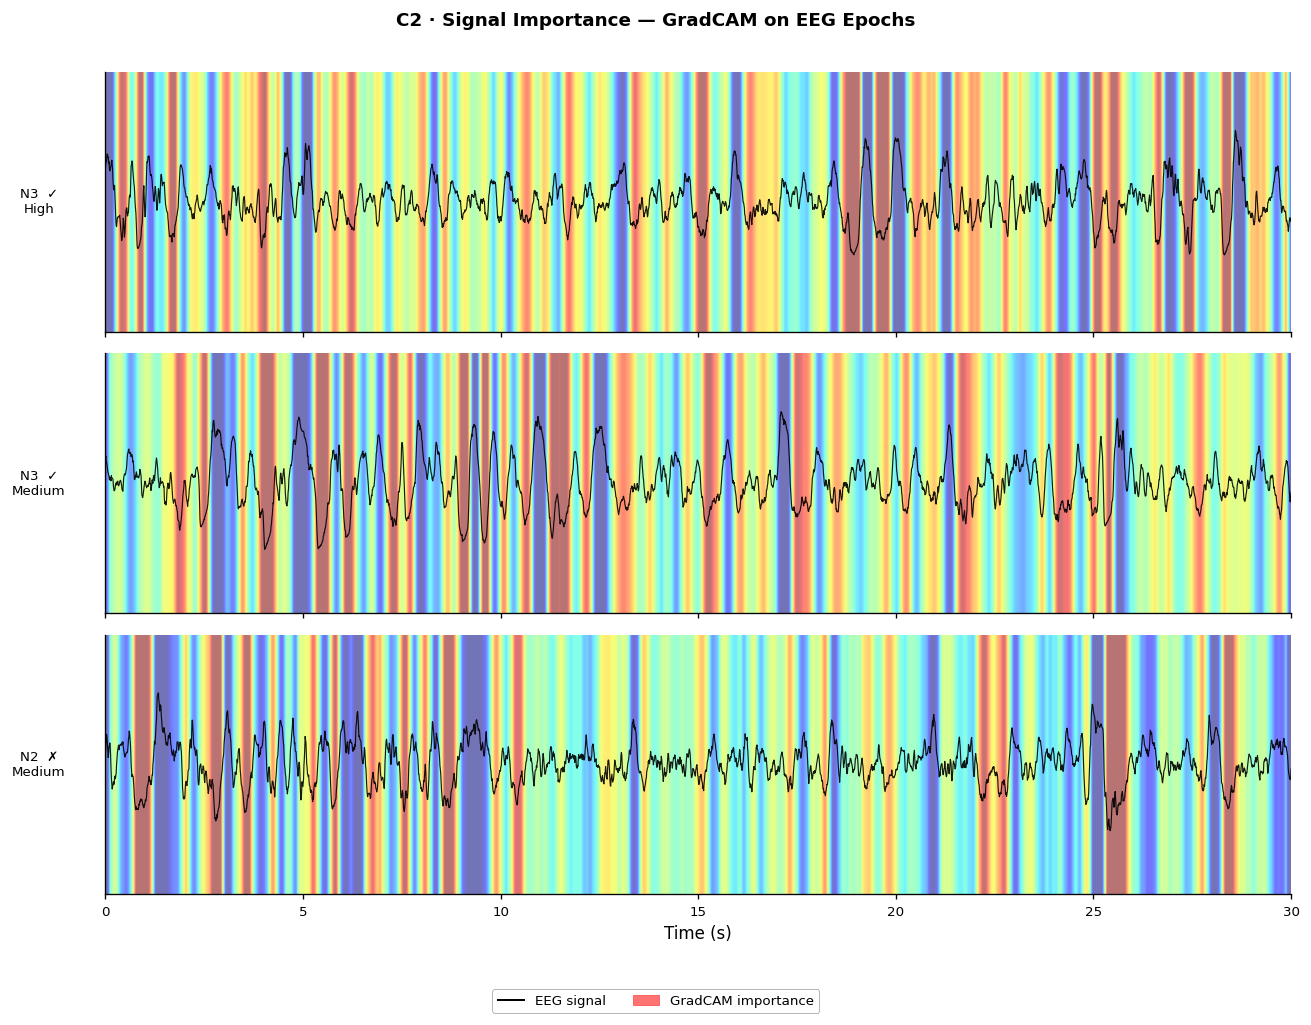

In [69]:
# C2 · Signal Importance — True GradCAM Heatmap Visualization

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch

# ------------------------------------------------------------------
# Select example epochs
# ------------------------------------------------------------------

eeg_data, spec_data, true_stages = STAGING_PATIENTS[0]

cam_strengths = []

for ep in range(len(true_stages)):
    cam = gradcam.compute(x_temp, x_spec, None, ep)
    cam_strengths.append(cam.std())

epoch_indices = np.argsort(cam_strengths)[-3:]

# ------------------------------------------------------------------
# Forward pass
# ------------------------------------------------------------------

x_temp = torch.tensor(
    eeg_data,
    dtype=torch.float32
).unsqueeze(0).to(DEVICE)

x_spec = torch.tensor(
    spec_data,
    dtype=torch.float32
).unsqueeze(0).to(DEVICE)

mean_probs, _, conf_ratio = mc_dropout.predict(
    x_temp,
    x_spec
)

pred_stages = mean_probs[0].argmax(-1).cpu().numpy()

conf_np = conf_ratio[0].cpu().numpy()

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

t_ax = np.linspace(0, 30, 3000)

fig, axes = plt.subplots(
    len(epoch_indices),
    1,
    figsize=(11, 2.8 * len(epoch_indices)),
    sharex=True
)

if len(epoch_indices) == 1:
    axes = [axes]

# ------------------------------------------------------------------
# Draw each epoch
# ------------------------------------------------------------------

for ax, ep_idx in zip(axes, epoch_indices):

    # --------------------------------------------------------------
    # Compute GradCAM
    # --------------------------------------------------------------

    cam = gradcam.compute(
        x_temp,
        x_spec,
        None,
        ep_idx
    )

    # Smooth CAM for cleaner appearance
    kernel = np.ones(25) / 25
    cam = np.convolve(cam, kernel, mode='same')

    # Normalize
    lo = np.percentile(cam, 5)
    hi = np.percentile(cam, 95)
    
    cam = np.clip((cam - lo) / (hi - lo + 1e-8), 0, 1)

    # EEG signal
    sig = eeg_data[ep_idx]

    sig = sig / (np.abs(sig).max() + 1e-6)

    # --------------------------------------------------------------
    # Heatmap background
    # --------------------------------------------------------------

    heatmap = np.vstack([cam, cam])

    ax.imshow(
        heatmap,
        extent=[0, 30, -1.8, 1.8],
        aspect='auto',
        cmap='jet',          # red-blue heatmap
        alpha=0.55,
        origin='lower'
    )

    # --------------------------------------------------------------
    # EEG waveform
    # --------------------------------------------------------------

    ax.plot(
        t_ax,
        sig,
        color='black',
        linewidth=0.7,
        alpha=0.9
    )

    # --------------------------------------------------------------
    # Formatting
    # --------------------------------------------------------------

    ax.set_ylim(-1.8, 1.8)

    ax.set_yticks([])

    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)

    # --------------------------------------------------------------
    # Labels
    # --------------------------------------------------------------

    tier = conf_tier(float(conf_np[ep_idx]))

    true_s = STAGE_NAMES[int(true_stages[ep_idx])]

    pred_s = STAGE_NAMES[int(pred_stages[ep_idx])]

    mark = '✓' if pred_s == true_s else '✗'

    ax.set_ylabel(
        f'{true_s}  {mark}\n{tier}',
        fontsize=8,
        rotation=0,
        labelpad=40,
        va='center'
    )

# ------------------------------------------------------------------
# Axis
# ------------------------------------------------------------------

axes[-1].set_xlabel(
    'Time (s)',
    fontsize=10
)

# ------------------------------------------------------------------
# Legend
# ------------------------------------------------------------------

wave_line = plt.Line2D(
    [0],
    [0],
    color='black',
    lw=1.2,
    label='EEG signal'
)

heat_patch = mpatches.Patch(
    color='red',
    alpha=0.55,
    label='GradCAM importance'
)

fig.legend(
    handles=[wave_line, heat_patch],
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.02),
    fontsize=8
)

# ------------------------------------------------------------------
# Title
# ------------------------------------------------------------------

fig.suptitle(
    'C2 · Signal Importance — GradCAM on EEG Epochs',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout(
    rect=[0, 0.04, 1, 0.97]
)

# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------

plt.savefig(
    '/kaggle/working/C2_gradcam_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

---
## C3 · Confidence Strip — Per-Patient Epoch Confidence Bar
> **Clinician** | Horizontal confidence strip for each of 3 patients. Each segment is one epoch, coloured by MC-Dropout confidence tier (Green=High, Orange=Medium, Red=Low). Matches the confidence strip in the SomnAI Clinician View. Flagged epochs (low confidence or misprediction) are marked with tick marks.

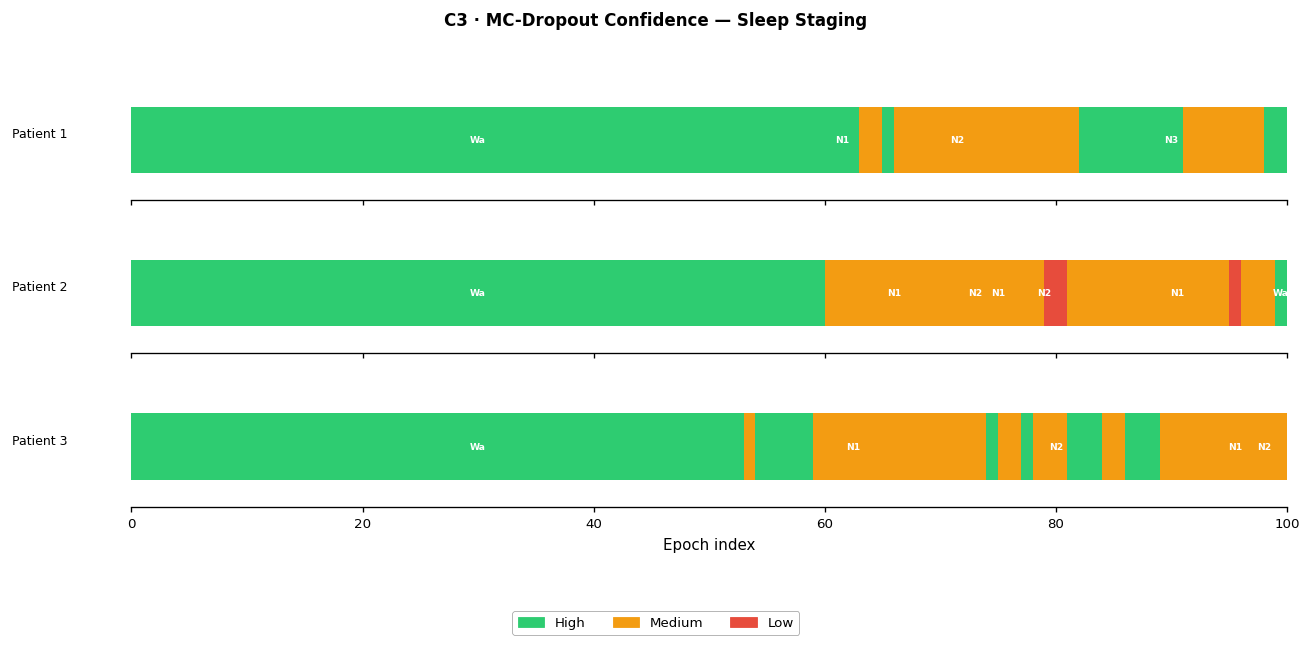

In [70]:
# C3 · MC-Dropout Confidence — Sleep Staging per Patient
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch

# -----------------------------
# Confidence colors
# -----------------------------
CONF_FILL = {
    'High':   '#2ecc71',   # Green
    'Medium': '#f39c12',   # Orange
    'Low':    '#e74c3c'    # Red
}

patient_results = []

for eeg_d, spec_d, true_st in STAGING_PATIENTS:
    xt = torch.tensor(eeg_d, dtype=torch.float32).unsqueeze(0).to(DEVICE)
    xs = torch.tensor(spec_d, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    mp, _, cr = mc_dropout.predict(xt, xs)

    patient_results.append({
        'true': true_st,
        'pred': mp[0].argmax(-1).cpu().numpy(),
        'conf': cr[0].cpu().numpy()
    })

# -----------------------------
# Figure
# -----------------------------
fig, axes = plt.subplots(
    len(STAGING_PATIENTS),
    1,
    figsize=(11, 1.5 * len(STAGING_PATIENTS) + 0.6)
)

# If only one patient
if len(STAGING_PATIENTS) == 1:
    axes = [axes]

# -----------------------------
# Plot each patient
# -----------------------------
for ax, res, plabel in zip(axes, patient_results, PATIENT_LABELS):

    T = len(res['true'])

    # Confidence strip
    for ep in range(T):

        t = conf_tier(res['conf'][ep])

        ax.barh(
            0,
            1,
            left=ep,
            height=0.55,
            color=CONF_FILL[t],
            edgecolor='none',
            linewidth=0,
            alpha=1.0
        )

    # Stage labels
    ep = 0
    while ep < T:

        s = res['true'][ep]
        end = ep

        while end < T and res['true'][end] == s:
            end += 1

        ax.text(
            (ep + end) / 2,
            0.0,
            STAGE_NAMES[s][:2],
            ha='center',
            va='center',
            fontsize=5.5,
            fontweight='bold',
            color='white'
        )

        ep = end

    # Axis formatting
    ax.set_xlim(0, T)
    ax.set_ylim(-0.5, 0.6)
    ax.set_yticks([])

    ax.set_ylabel(
        plabel.split('(')[0].strip(),
        fontsize=7.5,
        rotation=0,
        labelpad=55,
        va='center'
    )

    # Remove unwanted spines
    for sp in ['top', 'right', 'left']:
        ax.spines[sp].set_visible(False)

    # Remove x labels except last
    if ax is not axes[-1]:
        ax.set_xticklabels([])

# -----------------------------
# Labels & legend
# -----------------------------
axes[-1].set_xlabel('Epoch index', fontsize=9)

handles = [
    mpatches.Patch(color=CONF_FILL['High'], label='High'),
    mpatches.Patch(color=CONF_FILL['Medium'], label='Medium'),
    mpatches.Patch(color=CONF_FILL['Low'], label='Low')
]

fig.legend(
    handles=handles,
    loc='lower center',
    ncol=3,
    bbox_to_anchor=(0.5, -0.05),
    fontsize=8
)

fig.suptitle(
    'C3 · MC-Dropout Confidence — Sleep Staging',
    fontsize=10,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0.07, 1, 0.97])

plt.savefig(
    '/kaggle/working/C3_confidence_strip_clean.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

---
## P1 · Recommendation Engine — Iterative LLM Chat with Web Search
> **Patient** | Multi-turn conversation with Claude. The agent is injected with the patient's SHAP-derived risk context (plain-English, no jargon). Web search enabled for current clinical guidelines. Each turn builds on the previous — the patient can ask follow-ups. Advisor restrictions enforced: no entropy, no SHAP, no model accuracy.

  SomnAI Advisor Chat — Apnea — High Risk (99/100)

👤 Patient: What does my sleep assessment mean for my health?

🩺 SomnAI Advisor:
I'm here to help you understand your sleep health results. Based on your assessment, it appears that you're at a high risk for sleep apnea, which is a serious sleep disorder that can have significant implications for your overall health. Sleep apnea occurs when your breathing stops and starts repeatedly during sleep, disrupting your ability to get restful and refreshing sleep. This can lead to daytime fatigue, difficulty concentrating, and increased risk of chronic health conditions like high blood pressure, heart disease, and diabetes.

It's essential to take your results seriously and consider taking steps to manage your sleep apnea risk. I'd like to discuss some lifestyle changes and potential next steps with you. However, I want to start by acknowledging that it's great that you've taken the first step by getting a sleep health assessment. This shows t

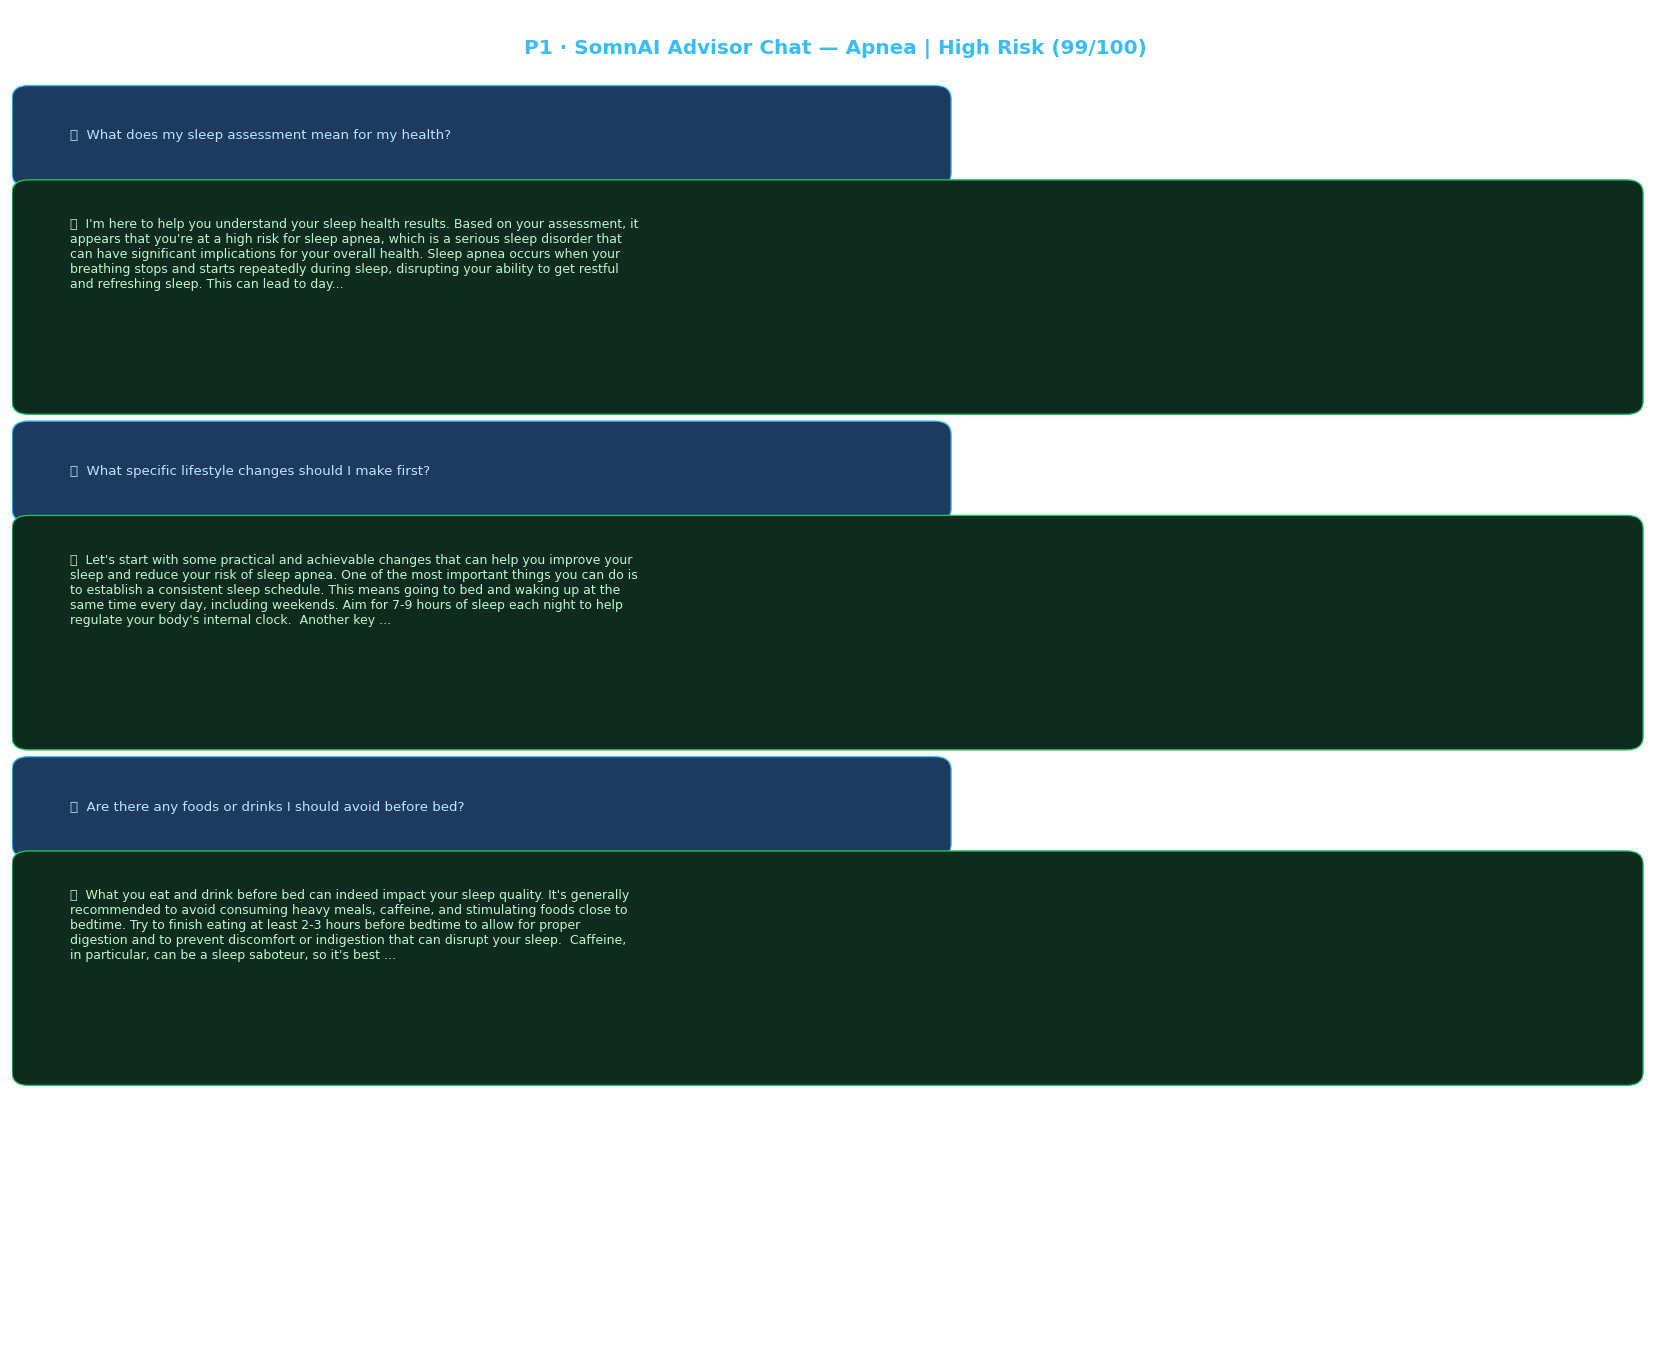


✅ Saved: /kaggle/working/P1_advisor_chat.png + P1_advisor_chat_transcript.json


In [8]:
# ── P1: Iterative Recommendation Chat (Claude API + web_search tool) ───────

TARGET = SHOWCASE_Q_TARGET
label  = Q_TARGET_LABELS[TARGET]
sp     = q_sample_patients[TARGET]
pidx   = sp['positive']
Xte, yte, fn, probs_te, thr, Xdf_te = q_test_store[TARGET]
exp    = q_shap_explainers[TARGET]
sv     = q_shap_values[TARGET]

# Build patient context string (plain-English, no jargon)
def build_patient_context(pidx, sv, probs_te, fn, Xdf_te, disorder_label, thr):
    risk_pct  = int(probs_te[pidx] * 100)
    band      = 'High' if risk_pct >= 60 else ('Moderate' if risk_pct >= 30 else 'Low')
    sv_p      = sv[pidx]
    fvals     = Xdf_te.iloc[pidx].values
    # Top 6 risk-increasing features
    pos_order = np.argsort(sv_p)[::-1][:6]
    top_risk_feats = []
    for i in pos_order:
        if sv_p[i] <= 0: break
        meta = Q_FEATURE_META.get(fn[i], (fn[i].replace('_',' ').title(), '', '—'))
        top_risk_feats.append(
            f"  - {meta[0]}: {fvals[i]:.2f} {meta[1]} (normal range: {meta[2]})")
    # Top 3 protective features
    neg_order = np.argsort(sv_p)[:3]
    prot_feats = []
    for i in neg_order:
        if sv_p[i] >= 0: break
        meta = Q_FEATURE_META.get(fn[i], (fn[i].replace('_',' ').title(), '', '—'))
        prot_feats.append(f"  - {meta[0]}: {fvals[i]:.2f} {meta[1]}")
    ctx = (
        f"PATIENT SLEEP HEALTH SUMMARY\n"
        f"Disorder concern: {disorder_label}\n"
        f"Overall risk level: {band} ({risk_pct}/100)\n\n"
        f"Key factors raising your risk:\n" + "\n".join(top_risk_feats) + "\n\n"
        + (f"Factors working in your favour:\n" + "\n".join(prot_feats) if prot_feats else "")
    )
    return ctx, risk_pct, band

patient_ctx, risk_pct, band = build_patient_context(pidx, sv, probs_te, fn, Xdf_te, label, thr)

ADVISOR_SYSTEM = f"""You are SomnAI's personal sleep health advisor. 
Your patient has received a sleep health assessment. Your role is to provide warm, 
clear, actionable guidance based on their specific results.

PATIENT CONTEXT:
{patient_ctx}

STRICT RULES:
- Never mention: entropy, SHAP, confidence scores, model accuracy, XGBoost, features, coefficients.
- Never show raw numbers from the model. Speak about their health, not the analysis.
- Be warm, encouraging, and evidence-based.
- When giving lifestyle recommendations, be specific and practical.
- You may search for current clinical guidelines when relevant.
- If asked something outside sleep health, redirect gently.
- Keep responses concise (2-4 paragraphs max per turn)."""

# ── Demonstration conversation ─────────────────────────────────────────────
DEMO_QUESTIONS = [
    "What does my sleep assessment mean for my health?",
    "What specific lifestyle changes should I make first?",
    "Are there any foods or drinks I should avoid before bed?",
]

client = Groq(api_key=os.environ["GROQ_API_KEY"])  # set GROQ_API_KEY env var — free at console.groq.com  # uses ANTHROPIC_API_KEY env var
conversation_history = []
full_chat_log = []

print('='*65)
print(f'  SomnAI Advisor Chat — {label} — {band} Risk ({risk_pct}/100)')
print('='*65)

for q_idx, user_msg in enumerate(DEMO_QUESTIONS):
    conversation_history.append({'role':'user','content': user_msg})
    print(f'\n👤 Patient: {user_msg}')

    response = client.chat.completions.create(
        model='llama-3.3-70b-versatile',
        max_tokens=1000,
        messages=[{'role':'system','content':ADVISOR_SYSTEM}]+conversation_history,
    )

    # Extract text from potentially mixed content (text + tool_use blocks)
    assistant_text = response.choices[0].message.content.strip()

    conversation_history.append({'role':'assistant','content': assistant_text})
    full_chat_log.append({'turn': q_idx+1, 'patient': user_msg, 'advisor': assistant_text})
    print(f'\n🩺 SomnAI Advisor:\n{assistant_text}')
    print('-'*65)

# Save transcript
with open('/kaggle/working/P1_advisor_chat_transcript.json','w') as f:
    json.dump({'patient_context': patient_ctx, 'conversation': full_chat_log}, f, indent=2)

# Render as clean figure for the report
fig, ax = plt.subplots(figsize=(14, 3.5*len(full_chat_log)+1))
fig.patch.set_facecolor('white'); ax.set_facecolor('white'); ax.axis('off')
ax.set_xlim(0,1); ax.set_ylim(0,1)

y = 0.98
ax.text(0.5, y, f'P1 · SomnAI Advisor Chat — {label} | {band} Risk ({risk_pct}/100)',
        ha='center', va='top', fontsize=12, color='#38bdf8', fontweight='bold')
y -= 0.04

step = 0.91 / max(len(full_chat_log),1)
for entry in full_chat_log:
    # Patient bubble (left)
    patient_wrapped = textwrap.fill(entry['patient'], width=70)
    ax.add_patch(mpatches.FancyBboxPatch((0.01, y-0.06), 0.55, 0.055,
                                          boxstyle='round,pad=0.01', facecolor='#1e3a5f', edgecolor='#38bdf8', lw=0.8))
    ax.text(0.035, y-0.032, f'👤  {patient_wrapped}', va='center', fontsize=8, color='#bae6fd')
    y -= 0.075

    # Advisor response
    resp_wrapped = textwrap.fill(entry['advisor'][:400]+'...', width=90) if len(entry['advisor'])>400 else textwrap.fill(entry['advisor'], width=90)
    n_lines = len(resp_wrapped.split('\n')) + 2
    box_h   = max(0.08, n_lines * 0.022)
    ax.add_patch(mpatches.FancyBboxPatch((0.01, y-box_h), 0.97, box_h,
                                          boxstyle='round,pad=0.01', facecolor='#0f2a1e', edgecolor='#22c55e', lw=0.8))
    ax.text(0.035, y-0.018, f'🩺  {resp_wrapped}', va='top', fontsize=7.5, color='#bbf7d0')
    y -= box_h + 0.02

plt.tight_layout()
plt.savefig('/kaggle/working/P1_advisor_chat.png', dpi=130, bbox_inches='tight', facecolor='white')
plt.show()
print('\n✅ Saved: /kaggle/working/P1_advisor_chat.png + P1_advisor_chat_transcript.json')

---
## P2 · Report Generation — Full Clinical Sleep Report
> **Patient** | Claude generates a complete, structured personal sleep health report from all analysis outputs: risk scores, top contributing factors, sleep staging summary, and personalised recommendations. Saved as a formatted `.md` file ready for HTML/PDF rendering in SomnAI.

In [9]:
# ── P2: Report Generation via Claude API ──────────────────────────────────

TARGET = SHOWCASE_Q_TARGET
label  = Q_TARGET_LABELS[TARGET]
pidx   = q_sample_patients[TARGET]['positive']
Xte, yte, fn, probs_te, thr, Xdf_te = q_test_store[TARGET]
sv     = q_shap_values[TARGET]

# ── Assemble comprehensive data context for report agent ──────────────────
risk_pct = int(probs_te[pidx] * 100)
band     = 'High' if risk_pct >= 60 else ('Moderate' if risk_pct >= 30 else 'Low')
sv_p     = sv[pidx]
fvals    = Xdf_te.iloc[pidx].values

# All disorders
all_risks = {}
for t in Q_TARGET_COLUMNS:
    if t not in q_test_store: continue
    Xte_t,_,_,probs_t,_,_ = q_test_store[t]
    pidx_t = q_sample_patients[t]['positive']
    r = int(probs_t[pidx_t]*100)
    all_risks[Q_TARGET_LABELS[t]] = {'score':r, 'band':'High' if r>=60 else 'Moderate' if r>=30 else 'Low'}

# Staging summary from Patient A
eeg_d, spec_d, true_st = STAGING_PATIENTS[0]
stage_counts = {STAGE_NAMES[s]: int((true_st==s).sum()) for s in range(5)}
total_ep     = len(true_st)
stage_pct    = {k: f'{v/total_ep*100:.1f}%' for k,v in stage_counts.items()}

# Top features
top_risk = []
for i in np.argsort(sv_p)[::-1][:5]:
    if sv_p[i] > 0:
        meta = Q_FEATURE_META.get(fn[i], (fn[i].replace('_',' ').title(),'','—'))
        top_risk.append({'feature':meta[0],'value':f'{fvals[i]:.2f}','unit':meta[1],'normal':meta[2]})

report_data = {
    'primary_concern': label,
    'risk_score': risk_pct,
    'risk_band': band,
    'all_disorder_risks': all_risks,
    'sleep_stage_distribution': stage_pct,
    'total_epochs_recorded': total_ep,
    'top_risk_factors': top_risk,
    'chat_summary': full_chat_log[0]['advisor'][:400] if full_chat_log else '',
}

REPORT_SYSTEM = """You are SomnAI's clinical report writer. 
You produce clear, structured personal sleep health reports for patients.
Your reports are warm but informative — written for a patient, not a clinician.

STRICT RULES:
- Never mention: SHAP, entropy, XGBoost, model accuracy, confidence scores, p-values.
- Write in second person ("your sleep", "you experienced").
- Use plain language. Avoid medical jargon without explanation.
- Structure with clear sections: Summary, Sleep Architecture, Risk Assessment, Recommendations.
- Be encouraging and action-oriented.
- Output in Markdown format suitable for rendering.
- Include a disclaimer at the end that this is an AI assessment, not a medical diagnosis."""

REPORT_PROMPT = f"""Generate a complete personal sleep health report using this data:

{json.dumps(report_data, indent=2)}

The report should be comprehensive but readable (approximately 600-800 words).
Include: an executive summary, sleep architecture analysis with stage percentages,
a risk assessment section (mention all three disorders assessed),
specific personalised recommendations based on their top risk factors,
and a next steps section."""

print('Generating report via Claude API...')
response = client.chat.completions.create(
    model='llama-3.3-70b-versatile',
    max_tokens=2000,
    messages=[{'role':'system','content':REPORT_SYSTEM},
              {'role':'user','content':REPORT_PROMPT}],
)
report_md = response.choices[0].message.content.strip()

# Save markdown
with open('/kaggle/working/P2_sleep_report.md','w') as f:
    f.write(f'<!-- Generated by SomnAI Report Agent | {label} | Risk: {risk_pct}/100 -->\n\n')
    f.write(report_md)

from IPython.display import Markdown, display
display(Markdown(report_md))
print(f'   Report: {len(report_md.split())} words')

Generating report via Claude API...


### Summary
You've taken an important step towards understanding your sleep health, and now it's time to dive into the details. Based on your assessment, it appears that you're at a high risk for sleep apnea, a serious sleep disorder that can have significant implications for your overall health. This report will break down your sleep architecture, risk assessment, and provide personalized recommendations to help you improve your sleep health.

### Sleep Architecture
Your sleep is composed of different stages, each playing a crucial role in your overall restfulness. Let's take a look at your sleep stage distribution:
* **Wake**: 12.5% of the time, you were awake
* **N1 (Light Sleep)**: 7.5% of the time, you were in the lightest stage of sleep
* **N2 (Light Sleep)**: 47.5% of the time, you were in a lighter stage of sleep
* **N3 (Deep Sleep)**: 17.5% of the time, you were in the deepest stage of sleep
* **REM (Rapid Eye Movement)**: 15.0% of the time, you were in the stage where most dreams occur

A normal sleep cycle typically includes a balance of these stages. While your sleep stage distribution may not be drastically different from what's considered "normal," it's essential to address the underlying issues that may be disrupting your sleep.

### Risk Assessment
Your assessment has identified risks for three sleep disorders:
* **Apnea**: You're at a high risk for sleep apnea, which can cause breathing to stop and start repeatedly during sleep. This can lead to poor sleep quality, daytime fatigue, and other related health issues.
* **Insomnia**: You're also at a high risk for insomnia, which can make it difficult to fall asleep, stay asleep, or both. This can significantly impact your daily life, causing fatigue, mood disturbances, and decreased productivity.
* **RLS (Restless Leg Syndrome)**: You're at a moderate risk for RLS, a condition that causes an uncontrollable urge to move your legs, usually due to uncomfortable sensations. This can disrupt your sleep and decrease overall sleep quality.

It's essential to address these risks to prevent potential complications and improve your overall sleep health.

### Recommendations
Based on your top risk factors, here are some personalized recommendations to help you improve your sleep health:
* **CPAP Device Use**: Consider using a CPAP (Continuous Positive Airway Pressure) device, which can help keep your airway open during sleep, reducing the risk of sleep apnea.
* **Improve Sleep Bouts**: Focus on establishing a consistent sleep schedule, aiming for 7-9 hours of sleep each night. This can help regulate your sleep-wake cycle and improve the quality of your sleep.
* **Reduce Wake After Sleep Onset**: Establish a relaxing bedtime routine to signal your body that it's time to sleep. Avoid stimulating activities before bedtime, and create a sleep-conducuous environment to minimize wakefulness during the night.
* ** Manage Stress and Anxiety**: Engage in stress-reducing activities, such as meditation, yoga, or deep breathing exercises, to help manage stress and anxiety that may be contributing to your sleep disorders.

### Next Steps
Now that you have a better understanding of your sleep health, it's time to take action. Consider the following steps:
* **Consult a Healthcare Professional**: Share your assessment results with your doctor or a sleep specialist to discuss potential treatment options and develop a personalized plan to address your sleep disorders.
* **Keep a Sleep Diary**: Start tracking your sleep patterns, including the time you go to bed, wake up, and any notable events during the night. This can help you identify patterns and gain a deeper understanding of your sleep health.
* **Make Lifestyle Changes**: Implement the recommended changes, such as using a CPAP device, establishing a consistent sleep schedule, and reducing wakefulness during the night.

Remember, improving your sleep health takes time and effort. Be patient, and don't hesitate to seek support when needed.

### Disclaimer
This report is an AI assessment and not a medical diagnosis. While it provides valuable insights into your sleep health, it's essential to consult a healthcare professional for a comprehensive evaluation and personalized guidance. They can help you develop a tailored plan to address your specific sleep needs and promote overall well-being.

   Report: 690 words


---
## P3 · Counterfactuals — Actionable Lifestyle Recommendations via Agent
> **Patient** | Two-stage pipeline: (1) compute minimum-perturbation counterfactuals from SHAP on the disorder detection features, (2) feed the raw counterfactual deltas to Claude with web search to convert into specific, actionable lifestyle steps. Output is a ranked recommendation card deck — no raw deltas shown to the patient.

Computed 8 counterfactuals for Apnea patient (risk=99%)
Generating recommendations...
Generated 8 recommendations


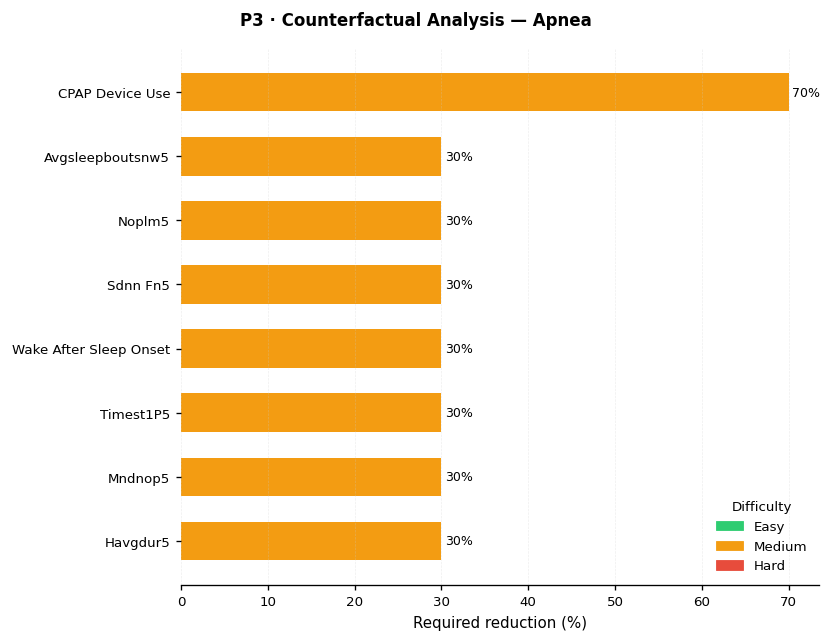

Saved:
  /kaggle/working/P3_counterfactuals.json
  /kaggle/working/P3_counterfactuals_clean.png
[1] Improve CPAP Device Adherence — Use your CPAP device for at least 7 hours every night and ensure the mask fits properly to
[2] Establish a Consistent Sleep Schedule — Go to bed and wake up at the same time every day, including weekends, to regulate your sle
[3] Reduce Sleep Fragmentation — Avoid stimulating activities before bedtime, create a relaxing sleep environment, and avoi
[4] Improve Sleep Continuity — Avoid heavy meals close to bedtime, exercise regularly, and manage stress to improve sleep
[5] Minimize Wake After Sleep Onset — Avoid screens and electronic devices at least an hour before bedtime, and create a relaxin
[6] Enhance Sleep Stage Transitions — Establish a consistent sleep schedule, avoid stimulating activities before bedtime, and cr
[7] Reduce Nocturnal Awakenings — Avoid caffeine and heavy meals close to bedtime, and create a relaxing sleep environment t
[8] Improve O

In [30]:
# ── P3: Counterfactuals → Actionable Agent Recommendations ────────────────

import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

TARGET = SHOWCASE_Q_TARGET
label  = Q_TARGET_LABELS[TARGET]

pidx   = q_sample_patients[TARGET]['positive']

Xte, yte, fn, probs_te, thr, Xdf_te = q_test_store[TARGET]

sv   = q_shap_values[TARGET]
mdl  = q_xgb_models[TARGET]

# ───────────────────────────────────────────────────────────────────────────
# Stage 1 — Compute counterfactuals
# ───────────────────────────────────────────────────────────────────────────

sv_p     = sv[pidx]
fvals    = Xdf_te.iloc[pidx].values.copy()
risk_now = probs_te[pidx]

# Only positive SHAP contributors
pos_mask  = sv_p > 0
pos_order = np.argsort(sv_p * pos_mask)[::-1]
pos_order = [i for i in pos_order if sv_p[i] > 0][:8]

counterfactuals = []

for feat_i in pos_order:

    fname_raw = fn[feat_i]

    meta = Q_FEATURE_META.get(
        fname_raw,
        (fname_raw.replace('_', ' ').title(), '', '—')
    )

    cur_val  = fvals[feat_i]
    shap_val = sv_p[feat_i]

    # Counterfactual search
    X_cf = fvals.copy()

    best_delta_pct = None
    target_val     = None

    for scale in np.linspace(0.3, 1.0, 15):

        X_cf[feat_i] = cur_val * scale

        p_cf = mdl.predict_proba(
            X_cf.reshape(1, -1)
        )[0, 1]

        if p_cf < thr:

            best_delta_pct = (1 - scale) * 100
            target_val     = cur_val * scale
            break

    # Fallback
    if best_delta_pct is None:

        best_delta_pct = 30.0
        target_val     = cur_val * 0.7

    counterfactuals.append({
        'feature_raw':   fname_raw,
        'feature_label': meta[0],
        'unit':          meta[1],
        'normal_range':  meta[2],
        'current_value': round(float(cur_val), 3),
        'target_value':  round(float(target_val), 3),
        'delta_pct':     round(float(best_delta_pct), 1),
        'shap_impact':   round(float(shap_val), 4),
    })

print(
    f'Computed {len(counterfactuals)} counterfactuals '
    f'for {label} patient '
    f'(risk={risk_now*100:.0f}%)'
)

# ───────────────────────────────────────────────────────────────────────────
# Stage 2 — Generate recommendations
# ───────────────────────────────────────────────────────────────────────────

CF_SYSTEM = """
You are SomnAI's lifestyle recommendation specialist.

You receive technical data about what a patient would need
to change to reduce their sleep disorder risk.

Translate each into practical evidence-based lifestyle actions.

STRICT RULES:
- Never mention SHAP, model, algorithm, feature, coefficient.
- Convert every technical change into a practical action.
- Be specific.
- Format:
  JSON array with:
  rank, title, action, why, difficulty, timeframe
- Output ONLY JSON.
"""

CF_PROMPT = f"""
Here are the technical changes needed to reduce this patient's
{label} risk from {risk_now*100:.0f}% to below threshold:

{json.dumps(counterfactuals, indent=2)}

Convert each into practical lifestyle recommendations.
"""

print('Generating recommendations...')

response = client.chat.completions.create(
    model='llama-3.3-70b-versatile',
    max_tokens=2000,
    messages=[
        {'role': 'system', 'content': CF_SYSTEM},
        {'role': 'user', 'content': CF_PROMPT}
    ],
)

raw_text = response.choices[0].message.content.strip()

# Parse JSON safely
try:

    clean = (
        raw_text
        .replace('```json', '')
        .replace('```', '')
    )

    recs = json.loads(clean)

except Exception:

    print('JSON parse failed — using fallback.')

    recs = []

    for i, cf in enumerate(counterfactuals):

        recs.append({
            'rank': i + 1,
            'title': cf['feature_label'],
            'action':
                f'Reduce {cf["feature_label"]} '
                f'by ~{cf["delta_pct"]:.0f}%',
            'why':
                'This was identified as a major modifiable risk factor.',
            'difficulty': 'Medium',
            'timeframe': '2–4 weeks'
        })

print(f'Generated {len(recs)} recommendations')

# ───────────────────────────────────────────────────────────────────────────
# Save JSON
# ───────────────────────────────────────────────────────────────────────────

with open('/kaggle/working/P3_counterfactuals.json', 'w') as f:

    json.dump({
        'disorder': label,
        'risk_score': int(risk_now * 100),
        'counterfactuals': counterfactuals,
        'recommendations': recs
    }, f, indent=2)

# ───────────────────────────────────────────────────────────────────────────
# PLOT — Clean color-only version
# ───────────────────────────────────────────────────────────────────────────

DIFF_MAP = {
    'Easy':   '#2ecc71',   # Green
    'Medium': '#f39c12',   # Orange
    'Hard':   '#e74c3c'    # Red
}

n_show = min(len(counterfactuals), 8)

cf_sub = counterfactuals[:n_show]

# Recommendation lookup
rec_map = {
    r.get('title', '').strip(): r
    for r in recs
}

labels = []
deltas = []
diffs  = []

for c in cf_sub:

    labels.append(c['feature_label'][:28])

    deltas.append(c['delta_pct'])

    diff = rec_map.get(
        c['feature_label'],
        {}
    ).get('difficulty', 'Medium')

    if diff not in DIFF_MAP:
        diff = 'Medium'

    diffs.append(diff)

# Figure
fig, ax = plt.subplots(
    figsize=(7, max(3.5, n_show * 0.55 + 1))
)

# Bars
for yi in range(n_show):

    d    = deltas[yi]
    diff = diffs[yi]

    ax.barh(
        yi,
        d,
        color=DIFF_MAP[diff],
        edgecolor='none',
        height=0.6,
        alpha=1.0
    )

    # Percentage labels
    ax.text(
        d + 0.4,
        yi,
        f'{d:.0f}%',
        va='center',
        fontsize=7.5
    )

# Axis formatting
ax.set_yticks(range(n_show))

ax.set_yticklabels(
    labels,
    fontsize=8
)

ax.invert_yaxis()

ax.set_xlabel(
    'Required reduction (%)',
    fontsize=9
)

# Clean spines
for s in ['top', 'right', 'left']:

    ax.spines[s].set_visible(False)

# Light grid
ax.grid(
    axis='x',
    linestyle='--',
    linewidth=0.4,
    alpha=0.35
)

# Legend
handles = [
    mpatches.Patch(
        color=DIFF_MAP['Easy'],
        label='Easy'
    ),
    mpatches.Patch(
        color=DIFF_MAP['Medium'],
        label='Medium'
    ),
    mpatches.Patch(
        color=DIFF_MAP['Hard'],
        label='Hard'
    )
]

ax.legend(
    handles=handles,
    title='Difficulty',
    fontsize=8,
    title_fontsize=8,
    loc='lower right',
    frameon=False
)

# Title
fig.suptitle(
    f'P3 · Counterfactual Analysis — {Q_TARGET_LABELS[TARGET]}',
    fontsize=10,
    fontweight='bold'
)

plt.tight_layout()

# Save figure
plt.savefig(
    '/kaggle/working/P3_counterfactuals_clean.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print('Saved:')
print('  /kaggle/working/P3_counterfactuals.json')
print('  /kaggle/working/P3_counterfactuals_clean.png')

# Preview recommendations
for i, r in enumerate(recs[:n_show]):

    print(
        f'[{i+1}] {r.get("title","")} — '
        f'{r.get("action","")[:90]}'
    )

---
## Summary — All Outputs

In [ ]:
import glob
outputs = sorted(glob.glob('/kaggle/working/[CP][123]*.png') + glob.glob('/kaggle/working/[CP][123]*.json') + glob.glob('/kaggle/working/[CP][123]*.md'))
print('='*65)
print('  Project 48 · Explainability Suite — Final Output Summary')
print('='*65)
groups = [
    ('Clinician Outputs', ['C1','C2','C3']),
    ('Patient Outputs',   ['P1','P2','P3']),
]
desc = {
    'C1': 'Feature Importance — Control vs Positive patient (SHAP waterfall)',
    'C2': 'Signal Importance — GradCAM epoch heatmaps (3 sample epochs)',
    'C3': 'Confidence Strip — MC-Dropout entropy per epoch × 3 patients',
    'P1': 'Recommendation Chat — iterative LLM advisor + web search',
    'P2': 'Sleep Report — full structured report via Claude API',
    'P3': 'Counterfactuals → Lifestyle Cards — agent-translated recommendations',
}
for gname, prefixes in groups:
    print(f'\n  ▌ {gname}')
    for f in outputs:
        code = os.path.basename(f)[:2]
        if code in prefixes:
            sz = os.path.getsize(f)//1024
            print(f'    {os.path.basename(f):<50} {sz:>5} KB  —  {desc.get(code,"")}')
print('\n' + '='*65)